# initialize

In [ ]:
import os,sys,subprocess,glob,importlib,pickle,itertools,string
from datetime import datetime
import xarray as xr
import numpy as np
import pandas as pd
import scipy,math


from sup.sup_plotting import *
from sup.useful_functions import *

from preprocessing.load_pickle_1D import *

from sup.merged_ensembles import *

%load_ext autoreload
%autoreload 2

### reference data

In [2]:
# these ensembles are used for climatological statistics
reference_ensemble_names = [
        'ssp370-2025-LE-all',
        'piControl-LE-all',
    ]

def get_reference_data(var_name, climate='both'):
    if climate == 'hist':
        return ensembles['hist-eobs']['data'][var_name]
    else:
        l = []
        for ens_name in reference_ensemble_names:
            if climate in ens_name or climate == 'both':
                l.append(ensembles[ens_name]['data'][var_name].values)
        x = np.concatenate(l)
        x = xr.DataArray(
            x, dims=['sim','time'], coords=dict(sim=np.arange(x.shape[0]), time=np.arange(x.shape[1]))
        )
        return x

## return level threshold

In [3]:
def get_threshold(rt, climate='piControl'):
    if rt == 'av':
        return None
    l = []
    for ens_name in reference_ensemble_names:
        if climate in ens_name or climate == 'both':
            x = ensembles[ens_name]['data']['tas_anom'].mean('time').values
            
            l.append( weighted_quantile(x, (1 - 1/rt), sample_weight=ensembles[ens_name]['data']['weight']) )
    return np.mean(l)

# Preparation

Here data is loaded, pre-processed and some statistics are calculated.

In [ ]:
ensembles = prep_data()

In [ ]:
def get_prob_and_weight(ens, var_name='tas'):
    ens['data']['prob'] = ens['data'][var_name][:,0].squeeze() * 0
    abso = ens['data'][var_name].mean('time')
    ens['data']['prob'][:] = np.array([(abso >= a).astype(float).mean() for a in abso])
    ens['data']['weight'] = ens['data'][var_name].copy()[:,0].squeeze() * 0 + 1
    return ens

## LE

### LE-all

In [ ]:
for climate,year_start,year_stop in zip(climates, [2020,1850], [2030,1900]):
    ens = {
        'data' : {},
        'color' : ensembles[f"{climate}-initial"]['color'],
        'climate' : climate, 
        'marker' : '.',
        'linestyle' : '-',
    }

    for var,var_original in [
        ('tas', 'TREFHT'),
        ('pr', 'PRECT'),
        ('hfss', 'SHFLX'),
        ('hfls', 'LHFLX'),
        ('mrsos', 'SOILWATER_10CM'),
    ]:
        files = sorted(glob.glob(f'external_data/from_lim/daily/{var_original}/*'))
        with xr.open_mfdataset(files) as nc:
            x = nc[var_original][:, (nc.time.dt.year >= year_start) & (nc.time.dt.year <= year_stop) & np.isin(nc.time.dt.month.values, [6,7,8]) ].load()
            if var == 'tas':
                x -= 273.15
            if var == 'pr':
                x *= 24*60*60

            l = []
            for sim in x.sim.values:
                for year in np.unique(x.time.dt.year.values):
                    l.append(x.loc[sim,str(year)][:-2].assign_coords(dict(sim=f"{sim}-{year}", time=np.arange(0,90,1,'int'))))

            ens['data'][var] = xr.concat(l, dim='sim')


    ens = get_prob_and_weight(ens)
    ensembles[f'{climate}-LE-all'] = ens


### LE-moist

In [6]:
for climate in climates:
    ens = {k:v for k,v in ensembles[f'{climate}-LE-all'].items()}
    l = []
    for var in ens['data'].keys():
        l.append(ens['data'][var].sim.values)
    sims = l[0]
    for sims_ in l:
        sims = sims[np.isin(sims,sims_)]
    for var in ens['data'].keys():
        ens['data'][var] = ens['data'][var].loc[sims]
    ensembles[f'{climate}-LE-moist'] = ens

## CMIP6 piControl

In [ ]:
x = xr.open_mfdataset('external_data/from_levante/piControl_CMIP6/tas/*')['tas']
x = xr.DataArray(x,
                dims = ['sim','time'],
                coords = dict(sim=x.year.values, time=np.arange(x.shape[1]))
).load()

ens = {
    'data' : {},
    'color' : ensembles[f"piControl-initial"]['color'],
    'climate' : 'piControl', 
    'marker' : 'v',
    'linestyle' : '--',
}
ens['data']['tas'] = x
ens = get_prob_and_weight(ens)

ensembles[f'piControl-CMIP6-all'] = ens

# pre-processing

In [18]:
for climate in climates:
    print(climate, get_reference_data('tas', climate).mean(axis=1).values.mean())

ssp370-2025 19.68136
piControl 17.875847


In [19]:
reference_for_anomalies = xr.DataArray(
    np.array([get_reference_data('tas', climate).mean(axis=1).values.mean() for climate in climates]),
    dims = ['climate'],
    coords = dict(climate = climates),
)
xr.Dataset({'reference_for_anomalies':reference_for_anomalies}).to_netcdf('reference_for_anomalies.nc')

## Anomalies

In [20]:
for ens_name,ens in ensembles.items():
    ens['data']['tas_absolute'] = ens['data']['tas'].copy()

In [21]:
for climate in climates:
    ref_mean =  get_reference_data('tas_absolute', climate).mean(axis=1).mean()
    for ens_name,ens in ensembles.items():
        if climate in ens_name:
            ens['data']['tas_anom'] = ens['data']['tas'].copy() - ref_mean

In [22]:
for climate,year_start,year_stop in zip(climates, [2020,1850], [2030,1900]):
    with xr.open_mfdataset(f'external_data/from_lim/daily/TREFHT/*') as nc:
        ref = nc['TREFHT'][:, (nc.time.dt.year >= year_start) & (nc.time.dt.year <= year_stop)].mean().load()
    for ens_name,ens in ensembles.items():
        if climate in ens_name:
            ens['data']['tas_yearly_anom'] = ens['data']['tas_absolute'] - ref       


In [12]:
for climate in climates:
    seas_cycle = get_reference_data('tas_anom', climate).mean('sim').values
    for ens_name,ens in ensembles.items():
        if climate in ens_name:
            ens['data']['tas_seas_anom'] = ens['data']['tas_anom'] - seas_cycle           

# Heat statistics

Here some heat statistics are calculated for different ensembles an anomaly types.

In [24]:
for ens_name,ens in ensembles.items():
    ens['stats'] = {}

### General

In [ ]:
for anom_version in ['absolute', 'anom', 'yearly_anom', 'seas_anom']:
    for ens_name,ens in ensembles.items():
        if 'hist' not in ens_name and ens_name != '2025-LE-all':
            ens['stats'][f'TXm_{anom_version}'] = ens['data'][f'tas_{anom_version}'].max('time')   
            ens['stats'][f'tas_mean_{anom_version}'] = ens['data'][f'tas_{anom_version}'].mean('time')
            ens['stats'][f'T5Xm_{anom_version}'] = ens['data'][f'tas_{anom_version}'].rolling(time=5).mean().max('time')  
            ens['stats'][f'tas_trend_{anom_version}'] = ens['data'][f'tas_{anom_version}'].assign_coords(time=np.arange(90)).polyfit('time', 1)['polyfit_coefficients'][0,:]

### ndays and persistence

In [131]:
for anom_version, pctl_version in [
    ('absolute', 'piControl'),
    ('anom', 'piControl'),
    ('anom', 'clim'),
    ('seas_anom', 'piControl'),
    ('seas_anom', 'clim'),
]:
    for ens_name,ens in ensembles.items():
        climate = ens['climate']
        try:
            for p in [10,25,33,50,66,75,90,95,99]:
                if pctl_version == 'piControl':
                    thresh = np.percentile(ensembles['piControl-LE-all']['data'][f'tas_{anom_version}'], p)
                else:
                    thresh = np.percentile(ensembles[f'{climate}-LE-all']['data'][f'tas_{anom_version}'], p)

                p_names = [f'>{p}']
                conditions = [(ens['data'][f'tas_{anom_version}'] > thresh)]
                if p < 50:
                    p_names += [f'<{p}']
                    conditions += [(ens['data'][f'tas_{anom_version}'] < thresh)]

                for p_name, condition in zip(p_names, conditions):
                    ens['stats'][f'ndays_{anom_version}_{pctl_version}_{p_name}'] = (condition).sum('time')
                    
                    start,length = persistence_stats(condition)
                    ens['stats'][f'persist_max_{anom_version}_{pctl_version}_{p_name}'] = ens['data']['prob'].copy() * 0
                    ens['stats'][f'persist_mean_{anom_version}_{pctl_version}_{p_name}'] = ens['data']['prob'].copy() * 0
                    for sim_name in ens['data'][f'tas_{anom_version}'].sim.values:
                        if len(length[sim_name]) > 0:
                            ens['stats'][f'persist_max_{anom_version}_{pctl_version}_{p_name}'].loc[sim_name] = np.max(length[sim_name])
                            ens['stats'][f'persist_mean_{anom_version}_{pctl_version}_{p_name}'].loc[sim_name] = np.mean(length[sim_name])
        except:
            print(ens_name)


2025-LE-all
hist-eobs
2025-LE-all
hist-eobs
2025-LE-all
ssp370-2025-rea
piControl-rea
ssp370-2025-rea345
piControl-rea345
ssp370-2025-rea-dry
hist-eobs
2025-LE-all
ssp370-2025-rea
piControl-rea
ssp370-2025-rea345
piControl-rea345
ssp370-2025-rea-dry


### hwmdi

In [55]:
for anom_version, pctl_version in [
    ('absolute', 'piControl'),
    ('anom', 'piControl'),
    ('anom', 'clim'),
    ('seas_anom', 'piControl'),
    ('seas_anom', 'clim'),
]:
    for ens_name,ens in ensembles.items():
        try:
            climate = ens['climate']
            if pctl_version == 'same':
                t25 = np.percentile(get_reference_data(f'tas_{anom_version}'), 25)
                t75 = np.percentile(get_reference_data(f'tas_{anom_version}'), 75)
                t90 = np.percentile(get_reference_data(f'tas_{anom_version}'), 90)
            elif pctl_version == 'piControl':
                t25 = np.percentile(get_reference_data(f'tas_{anom_version}', 'piControl'), 25)
                t75 = np.percentile(get_reference_data(f'tas_{anom_version}', 'piControl'), 75)
                t90 = np.percentile(get_reference_data(f'tas_{anom_version}', 'piControl'), 90)
            else:
                t25 = np.percentile(get_reference_data(f'tas_{anom_version}', climate), 25)
                t75 = np.percentile(get_reference_data(f'tas_{anom_version}', climate), 75)
                t90 = np.percentile(get_reference_data(f'tas_{anom_version}', climate), 90)
            m = (ens['data'][f'tas_{anom_version}'] - t25 ) / ( t75 - t25 )
            hwd = ens['data'][f'tas_{anom_version}'] > t90
            start,length = persistence_stats(ens['data'][f'tas_{anom_version}'] > t90)
            ens['stats'][f'hwmdi_{anom_version}_{pctl_version}'] = ens['data']['prob'].copy() * 0
            hws = {}
            for sim_name in m.sim.values:
                hws[sim_name] = []
                for l,s in zip(length[sim_name],start[sim_name]):
                    hws[sim_name].append(m.loc[sim_name][s:s+l].values.sum())
                if len(hws[sim_name]) > 0:
                    ens['stats'][f'hwmdi_{anom_version}_{pctl_version}'].loc[sim_name] = np.max(hws[sim_name])
                    
        except:
            print(ens_name)

2025-LE-all
2025-LE-all
hist-eobs
2025-LE-all
ssp370-2025-rea
piControl-rea
ssp370-2025-rea345
piControl-rea345
ssp370-2025-rea-dry
hist-eobs
2025-LE-all
ssp370-2025-rea
piControl-rea
ssp370-2025-rea345
piControl-rea345
ssp370-2025-rea-dry


## smoothed time series

In [29]:
for rolling_window in [5,10]:
    for ens_name, ens in ensembles.items():
        #ens['data'] = {k:v for k,v in ens['data'].items() if 'd5mean' not in k}
        ens[f'data_d{rolling_window}mean'] = {}
        vars = list(ens['data'].keys())
        for var in vars:
            if 'time' in ens['data'][var].dims:
                ens[f'data_d{rolling_window}mean'][var] = ens['data'][var].copy().rolling(time=rolling_window).mean()[:,rolling_window-1::rolling_window]

# save ensemble pickle

In [79]:
with open('pickles/REA_heat_1D_stats.pkl', 'wb') as fl:
    pickle.dump({ens_name : {k:v for k,v in ens.items() if k != 'exp'} for ens_name,ens in ensembles.items()}, fl)

# load ensemble pickle

In [4]:
with open('pickles/REA_heat_1D_stats.pkl', 'rb') as fl:
    ensembles = pickle.load(fl)

# merged ensembles

Rare-event sampling ensembles of the same type are merged into one big ensemble.

In [66]:
for climate in climates:
    ens_name = f"{climate}-rea"
    ensembles[ens_name] = merge_ensembles(ensembles, [f"{climate}-x{i}" for i in range(1,6)], climate, ['tas', 'tas_anom', 'tas_absolute'])
    ee = rea_multi_ensemble(ensembles[ens_name])
    ensembles[ens_name]['class'] = ee

In [67]:
for climate in climates:
    ens_name = f"{climate}-rea345"
    ensembles[ens_name] = merge_ensembles(ensembles, [f"{climate}-x{i}" for i in range(3,6)], climate, ['tas', 'tas_anom', 'tas_absolute','mrsos','pr','hfss','hfls'])
    ee = rea_multi_ensemble(ensembles[ens_name])
    ensembles[ens_name]['class'] = ee

In [68]:
ens_name = f"ssp370-2025-rea-dry"
ensembles[ens_name] = merge_ensembles(ensembles, [f"ssp370-2025-dry-x{i}" for i in [6,9,11]] + [f"ssp370-2025-wet-x{i}" for i in [7,8,12]], climate, ['tas', 'tas_anom', 'tas_absolute', 'mrsos','pr','hfss','hfls'])
ee = rea_multi_ensemble(ensembles[ens_name])
ensembles[ens_name]['class'] = ee

In [69]:
ens_name = 'ssp370-2025-rea-dry'
ensembles[ens_name]['linestyle'] = '--'
ensembles[ens_name]['color'] = 'darkorange'
ensembles[ens_name]['label'] = 'REA (current-dry)'
ee = rea_multi_ensemble(ensembles[ens_name])
ensembles[ens_name]['class'] = ee

ensembles['ssp370-2025-rea345']['label'] = 'REA'

In [ ]:
for climate in climates:
    for type in ['LE-all','initial','LE-moist']:
        ens_name = f'{climate}-{type}'
        ee = LE_ensemble(ensembles[ens_name])
        ensembles[ens_name]['class'] = ee

ens_name = 'piControl-CMIP6-all'
ee = LE_ensemble(ensembles[ens_name])
ensembles[ens_name]['class'] = ee


In [70]:
'''
for climate in climates:
    ensembles[f"{climate}-LE-rea345"] = merge_ensembles([f"{climate}-x{i}" for i in range(3,6)] + [f"{climate}-LE-all"], climate, ['tas','mrsos','pr'])
'''

'\nfor climate in climates:\n    ensembles[f"{climate}-LE-rea345"] = merge_ensembles([f"{climate}-x{i}" for i in range(3,6)] + [f"{climate}-LE-all"], climate, [\'tas\',\'mrsos\',\'pr\'])\n'

# modify colors etc.

In [71]:
for climate,color in zip(climates, ['darkmagenta','darkcyan']):
    for t in ['rea','rea345']:
        ens_name = f'{climate}-{t}'
        ensembles[ens_name]['color'] = color

ensembles['piControl-LE-all']['hatch'] = '///'
ensembles['piControl-LE-all']['marker'] = '+'
ensembles['ssp370-2025-LE-all']['hatch'] = '\\\\\\'
ensembles['ssp370-2025-LE-all']['marker'] = '+'

ensembles['piControl-LE-moist']['hatch'] = '///'
ensembles['piControl-LE-moist']['marker'] = '+'
ensembles['ssp370-2025-LE-moist']['hatch'] = '\\\\\\'
ensembles['ssp370-2025-LE-moist']['marker'] = '+'

ensembles['piControl-CMIP6-all']['hatch'] = '...'
ensembles['piControl-CMIP6-all']['linestyle'] = ':'
ensembles['piControl-CMIP6-all']['marker'] = 'x'
ensembles['piControl-CMIP6-all']['color'] = 'aquamarine'


In [72]:
ensembles['piControl-CMIP6-all']['label'] = 'piControl'

In [73]:
ensembles['piControl-LE-all']['label'] = 'LE pre-ind.'
ensembles['ssp370-2025-LE-all']['label'] = 'LE current'

ensembles['piControl-LE-moist']['label'] = 'LE pre-ind.'
ensembles['ssp370-2025-LE-moist']['label'] = 'LE current'

ensembles['piControl-rea']['label'] = 'REA pre-ind.'
ensembles['ssp370-2025-rea']['label'] = 'REA current'

ensembles['piControl-rea345']['label'] = 'REA pre-ind.'
ensembles['ssp370-2025-rea345']['label'] = 'REA current'

ensembles['piControl-CMIP6-all']['label'] = 'piControl 1200 years'

# analysis

## return level plots

In [18]:
float((ensembles['piControl-rea']['data']['tas_anom'].mean('time') > get_threshold(100)).sum())

202.0

In [19]:
float((ensembles['ssp370-2025-rea']['data']['tas_anom'].mean('time') > get_threshold(100)).sum())

203.0

In [5]:
float((ensembles['ssp370-2025-LE-all']['data']['tas_anom'].mean('time') > get_threshold(100)).sum())

8.0

In [17]:
from scipy.stats import gaussian_kde

def plot_return_level_estimate(return_period, x_axis):
    fig,ax = plt.subplots(figsize=(5,4))
    for i,climate in enumerate(climates):
        for type in ['LE-all', 'rea', 'CMIP6-all']:
            ens_name = f'{climate}-{type}'
            if ens_name in ensembles.keys():
                ens = ensembles[ens_name]
                expect,l = ens['class'].return_level(return_period, 10000)
                # ax.axvline(expect, color=ens['color'], linestyle=ens['linestyle'])

                kde = gaussian_kde(l, bw_method=1)
                pdf = kde.pdf(x_axis)
                x1,x2 = np.percentile(l, [2.5,97.5])
                ax.plot(x_axis, pdf, color=ens['color'], linestyle=ens['linestyle'], label=f"{ens['label']}\n{np.mean(l):.2f} ({x1:.2f} - {x2:.2f})")
                x_ = np.linspace(x1,x2,100)
                if type == 'rea':
                    ax.fill_between(x_, x_*0, kde.pdf(x_), facecolor=ens['color'], edgecolor='none' ,alpha=0.2)
                else:
                    ax.fill_between(x_, x_*0, kde.pdf(x_), edgecolor=ens['color'], facecolor='none', hatch=ens['hatch'])
    ax.set_xlabel(f'temperature anomaly of {return_period}-year summers\n(relative to average summers)')
    return ax

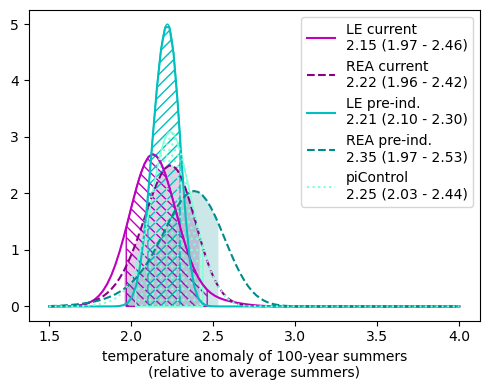

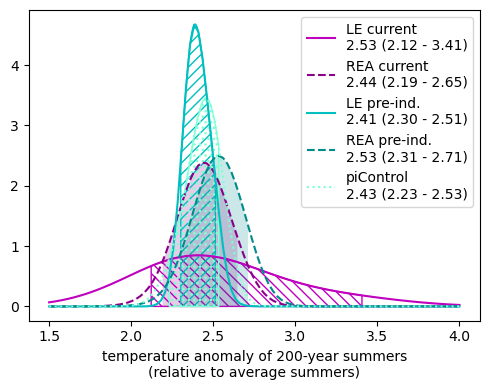

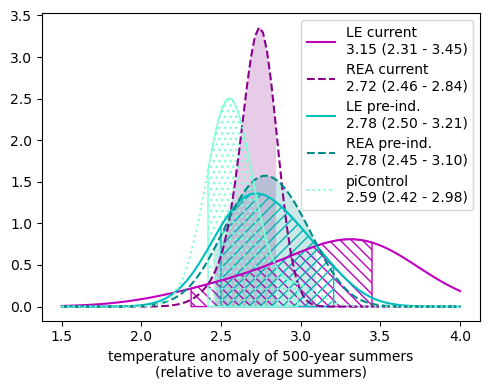

In [26]:
for return_period in [100,200,500]:
    ax = plot_return_level_estimate(return_period, np.linspace(1.5,4.0,100))
    ax.legend(fontsize=10)
    plt.tight_layout()
    savefig(f'return_level_plots/return_level_estimate_{return_period}')
    savefig(f'for_paper/return_level_plots/return_level_estimate_{return_period}', also_png=False)


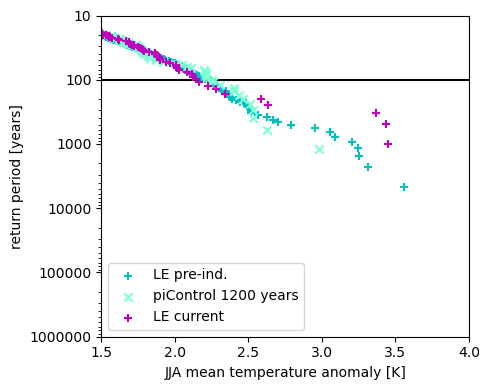

In [14]:
def LE_plot():
    fig, ax = plt.subplots(figsize=(5,4))
    ax.set_yscale('log')
    ax.set_ylabel('return period [years]')
    ax.set_xlabel('JJA mean temperature anomaly [K]')
    ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

    for climate in climates[::-1]:
        for type in ['LE-all', 'CMIP6-all']:
            ens_name = f'{climate}-{type}'
            if ens_name in ensembles.keys():
                ens = ensembles[ens_name]
                tas_mean = ens['data']['tas_anom'].mean('time')
                prob = np.array([np.average((tas_mean >= a).astype(float), weights=ens['data']['weight']) for a in tas_mean])
                ax.scatter(tas_mean, 1/prob, color=ens['color'], marker=ens['marker'], alpha=1, label=ens['label'])

    ax.set_yticks([1,10,100,1000,10000,10**5,10**6])
    ax.set_yticklabels([1,10,100,1000,10000,10**5,10**6])
    ax.set_xlim(1.5,4)
    ax.set_ylim(1000000, 10)
    plt.tight_layout()
    return ax

ax = LE_plot()
ax.legend()
for y in [100]:#,200,500]:
    ax.axhline(y, color='k', zorder=0)
savefig('return_level_plots/return_plot_zoom_LE')

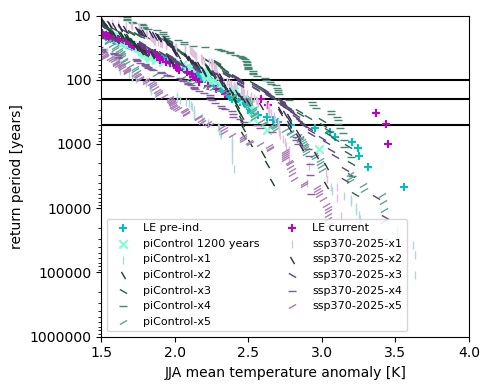

In [25]:
ax = LE_plot()
for climate in climates[::-1]:
    for i in range(1,6):
        ens_name = f"{climate}-x{i}"
        ens = ensembles[ens_name]
        ee = rea_multi_ensemble(ensembles[ens_name])
        tas_mean = ens['data']['tas_anom'].mean('time')
        prob = np.array([ee.exceedance_probability(a, n_bootstrap=0) for a in tas_mean.values])
        ax.scatter(tas_mean, 1/prob, color=ens['color'], marker=ens['marker'], label=ens_name)

handles, labels = ax.get_legend_handles_labels()
labels = labels[:2] + labels[3:8] + [labels[2]] + labels[8:]
handles = handles[:2] + handles[3:8] + [handles[2]] + handles[8:]
ax.legend(handles, labels, fontsize=8, ncol=2)
for y in [100,200,500]:
    ax.axhline(y, color='k', zorder=0)
savefig('return_level_plots/return_plot_zoom_LE+rea_individual_raw')
savefig(f'for_paper/return_level_plots/return_plot_zoom_LE+rea_individual_raw', also_png=False)


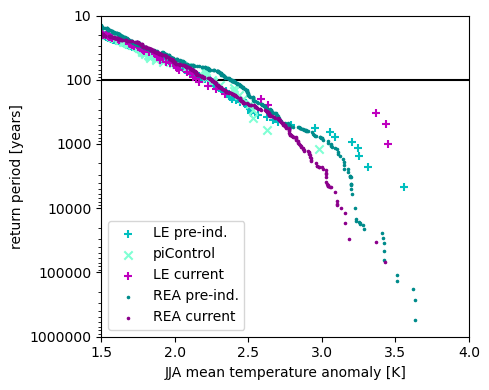

In [21]:
ax = LE_plot()
for climate in climates[::-1]:
    ens_type = 'rea'
    ens_name = f"{climate}-{ens_type}"
    ens = ensembles[ens_name]
    
    tas_mean = ens['data']['tas_anom'].mean('time')
    prob = np.array([ens['class'].exceedance_probability(a, n_bootstrap=0) for a in tas_mean.values])

    ax.scatter(tas_mean, 1/prob, color=ens['color'], marker='.', s=10, label=ens['label'])
ax.legend()
for y in [100]:#,200,500]:
    ax.axhline(y, color='k', zorder=0)
savefig('return_level_plots/return_plot_zoom_LE+rea')


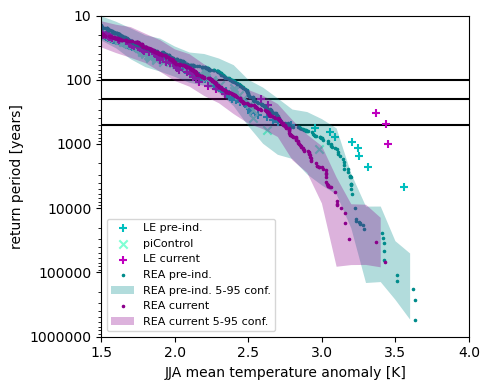

In [27]:
ax = LE_plot()
for climate in climates[::-1]:
    ens_type = 'rea'
    ens_name = f"{climate}-{ens_type}"
    ens = ensembles[ens_name]
    
    tas_mean = ens['data']['tas_anom'].mean('time')
    prob = np.array([ens['class'].exceedance_probability(a, n_bootstrap=0) for a in tas_mean.values])
    
    ax.scatter(tas_mean, 1/prob, color=ens['color'], marker='.', s=10, label=ens['label'])

    x_axis,up,lo = np.array([]),np.array([]),np.array([])
    for a in np.arange(1.5,4,0.1):
        y,p = ens['class'].exceedance_probability(a, n_bootstrap=10000)
        p = p[p > 0]
        if len(p) > 10:
            r = 1/p
            up = np.append(up, np.percentile(r, 95))
            lo = np.append(lo, np.percentile(r, 5))
            x_axis = np.append(x_axis, a)
    ax.fill_between(x_axis, up, lo, alpha=0.3, facecolor=ens['color'], edgecolor='none', label=f"{ens['label']} 5-95 conf.")
for y in [100,200,500]:
    ax.axhline(y, color='k', zorder=0)
ax.legend(fontsize=8)
savefig('return_level_plots/return_plot_zoom_LE+rea_confidence')
savefig(f'for_paper/return_level_plots/return_plot_zoom_LE+rea_confidence', also_png=False)

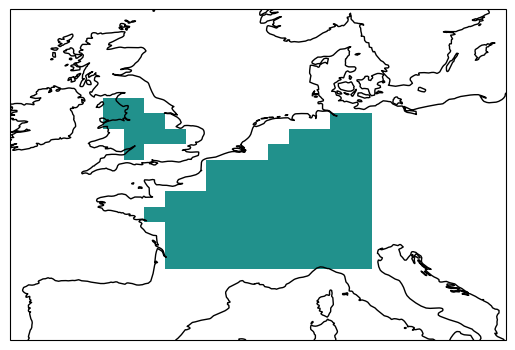

In [38]:
fig,ax = plt.subplots(subplot_kw=dict(projection=cartopy.crs.PlateCarree()))
ax.coastlines()
ax.set_extent([-10,20,40,60], crs=cartopy.crs.PlateCarree())
mask = xr.open_dataarray('wEU.nc')
mask.values[mask == 0] = np.nan
mask = mask * 0 + 1
ax.pcolormesh(mask.lon, mask.lat, mask, transform=cartopy.crs.PlateCarree(), vmin=0, vmax=2)
savefig('region_wEU')

## diff in expected values

In [80]:
def plot_table(ensemble_details, line_details, indicator_details):
    fig,ax = plt.subplots(figsize=(len(indicator_details)*0.8 + 2.5, len(line_details)*0.5 + 1))
    ax.axis('off')
    for i,line in enumerate(line_details):
        if line is None:
            pass
        else:
            i_, rt, anom_version, pctl_version, label = line
            ax.annotate(label, xy=(len(indicator_details) + 0.2, i+0.5), ha='left',  va='center', clip_on=False)
        
            for p,indicator,p_name,unit,relative,maxabs,round_digits in indicator_details:

                norm = matplotlib.colors.Normalize(vmin=-maxabs, vmax=maxabs)

                if i == 0:
                    ax.annotate(indicator, xy=(p+0.5,-0.2), ha='center', rotation=0, annotation_clip=False)
                if indicator in ['TXm', 'T5Xm', 'tas_trend', 'XFcold30']:
                    x_name = f'{indicator}_{anom_version}'
                elif indicator == 'hwmdi':
                    x_name = f'{indicator}_{anom_version}_{pctl_version}'
                else:
                    x_name = f'{p_name}_{anom_version}_{pctl_version}_{indicator}'


                if indicator in ['TXm', 'T5Xm', 'tas_trend', 'XFcold30'] and pctl_version == 'clim' and anom_version == 'anom':
                    pass
                else:
                    for j,comparison,marker,s in ensemble_details:
                        
                        if rt == 'av':
                            thresh = None
                        else:
                            thresh = get_threshold(rt, ensembles[comparison.split(' vs ')[-1]]['climate'])
                        
                        ref,ref_bs = ensembles[comparison.split(' vs ')[-1]]['class'].expected_value(x_name, 'stats', thresh, 1000)
                        y = ensembles[comparison.split(' vs ')[0]]['class'].expected_value(x_name, 'stats', thresh, 0)

                        if isinstance(ref, xr.DataArray):
                            ref = float(ref)
                            y = float(y)

                        if relative:
                            diff = (y - ref) / ref * 100
                        else:
                            diff = y - ref
                        
                        diff = np.round(float(diff), round_digits)
                        if round_digits == 0:
                            diff = int(diff)

                        ax.fill_between([p,p+1], [i+j,i+j], [i+0,i+1], color=cmap(norm(diff)), edgecolor='k', linewidth=0.2)
                        if y > np.percentile(ref_bs, 97.5) or y < np.percentile(ref_bs, 2.5):
                            ax.annotate(f" {diff}{unit}", xy=(p+0.75-j*0.5,i+0.25+j*0.5), ha='center', va='center', zorder=10, color = {True:'w', False:'k'}[np.abs(diff)> maxabs*0.5], fontsize=8)

                        if i_ == 0 and p == 0:
                            posx = len(indicator_details)+2.5
                            ax.fill_between([posx,posx+1], [i+j,i+j], [i+0,i+1], color='w', edgecolor='k', linewidth=0.2)
                            ax.scatter([posx+0.75-j*0.5],[i+0.25+j*0.5], marker=marker, color='k', s=s, zorder=10)
                            if j == 1:
                                if rt == 'av':
                                    ax.annotate(f"all summers", xy=(-0.1,i), fontsize=12, rotation=90, ha='right', va='top')
                                else:
                                    ax.annotate(f"{rt}-year summers", xy=(-0.1,i), fontsize=12, rotation=90, ha='right', va='top')


    ax.set_ylim(ax.get_ylim()[::-1])
    ax.set_xlim(-0.2,len(indicator_details)+3.5)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    #cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', extend='both', pad=0.01, shrink=0.6)
    #cbar.set_label(label='relative change [%]', fontsize=10, labelpad=10)
    plt.tight_layout()


In [81]:
ensemble_details_avini = [
    (0, 'ssp370-2025-initial vs piControl-initial', '$ini$', 200),
    (1, 'ssp370-2025-LE-all vs piControl-LE-all', '$LE$', 150),
]

In [82]:
ensemble_details_av = [
    (1, 'ssp370-2025-LE-all vs piControl-LE-all', '$LE$', 150),
]

In [83]:
ensemble_details_100 = [
    (0, 'ssp370-2025-rea vs piControl-rea', '$REA$', 200),
    (1, 'ssp370-2025-LE-all vs piControl-LE-all', '$LE$', 150),
]

In [84]:
cmap = matplotlib.colormaps['RdBu_r']

line_details_av = [
    (0, 'av', 'absolute', 'piControl', 'raw'),
    (1, 'av', 'anom', 'piControl', 'beyond climatological shift in JJA mean'),
    (2, 'av', 'anom', 'clim', 'beyond climatological shift in JJA mean\nwith climate-specific thresholds'),
    (3, 'av', 'seas_anom', 'piControl', 'beyond climatological shift\nin seasonal cycle'),
]

line_details_100 = [
    (0, 100, 'absolute', 'piControl', 'raw'),
    (1, 100, 'anom', 'piControl', 'beyond climatological shift in JJA mean'),
    (2, 100, 'anom', 'clim', 'beyond climatological shift in JJA mean\nwith climate-specific thresholds'),
    (3, 100, 'seas_anom', 'piControl', 'beyond climatological shift\nin seasonal cycle'),
]

In [85]:
standard_indicator_details = [
            (0, 'TXm', None, 'K', False, 3, 1),
            (1, 'T5Xm', None, 'K', False, 3, 1),
            (2, 'hwmdi', None, '%', True, 100, 0),
            ]

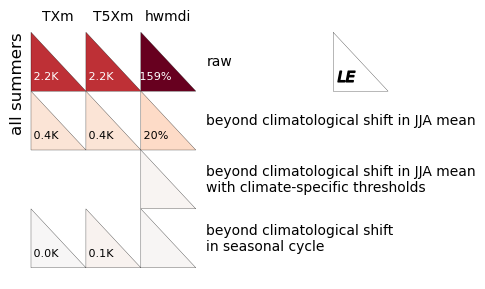

In [86]:
plot_table(ensemble_details_av, line_details_av, standard_indicator_details)
savefig(f"diff_tables/diff_general_indicators_average")

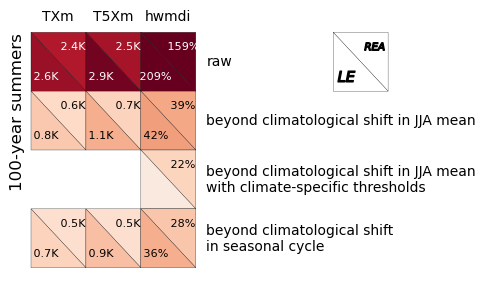

In [87]:
plot_table(ensemble_details_100, line_details_100, standard_indicator_details)
savefig(f"diff_tables/diff_general_indicators_100")

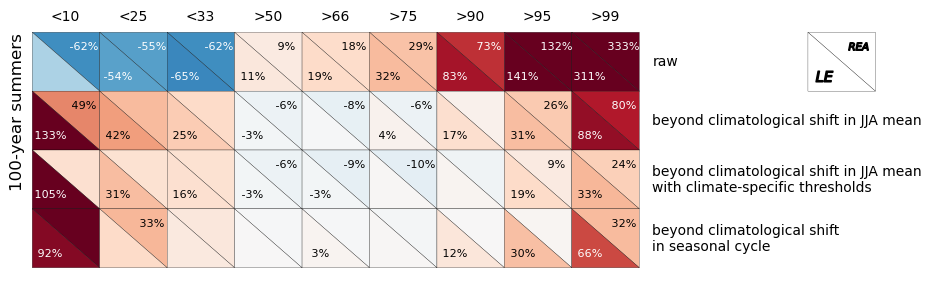

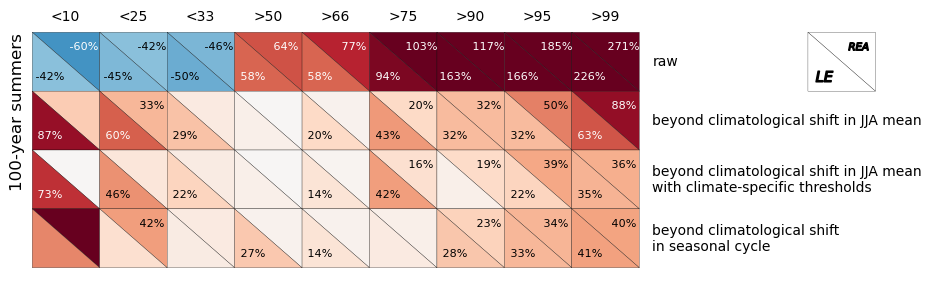

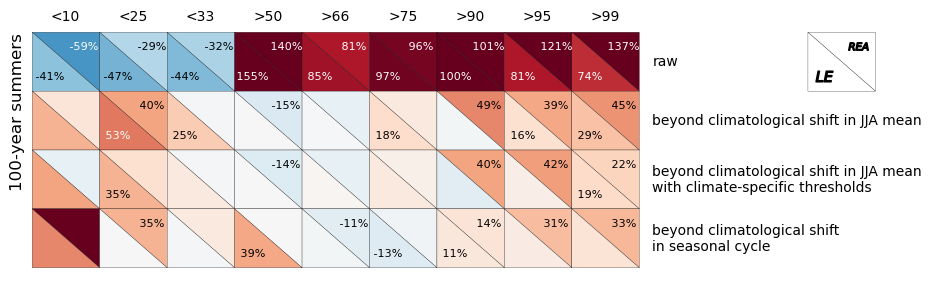

In [89]:
for indicator in ['ndays','persist_max','persist_mean']:
    indicator_details = [(i, name, indicator, '%', True, 100, 0) for i,name in enumerate(['<10', '<25', '<33', '>50', '>66', '>75', '>90', '>95', '>99'])]
    plot_table(ensemble_details_100, line_details_100, indicator_details)
    savefig(f"diff_tables/diff_{indicator}_100")

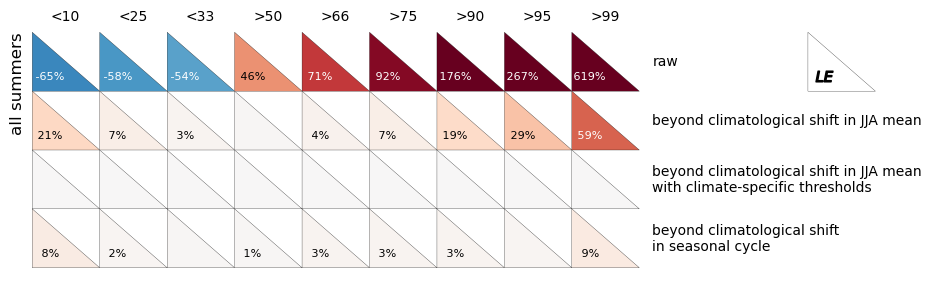

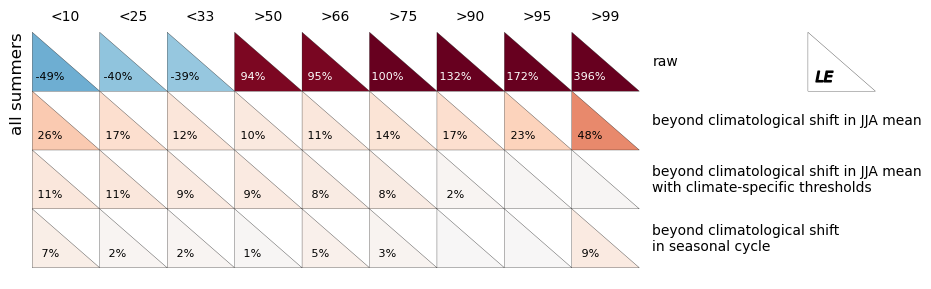

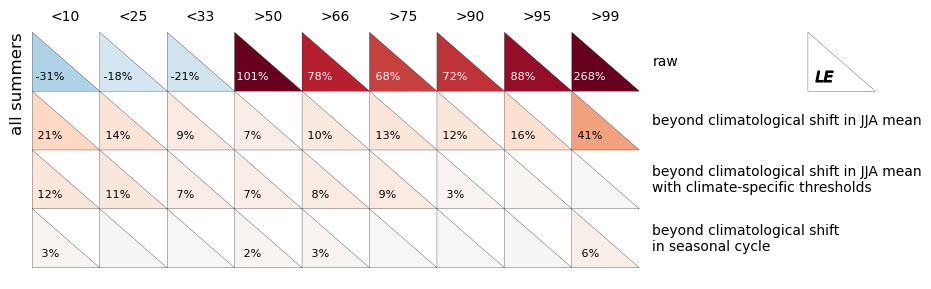

In [91]:
for indicator in ['ndays','persist_max','persist_mean']:
    indicator_details = [(i, name, indicator, '%', True, 100, 0) for i,name in enumerate(['<10', '<25', '<33', '>50', '>66', '>75', '>90', '>95', '>99'])]
    plot_table(ensemble_details_av, line_details_av, indicator_details)
    savefig(f"diff_tables/diff_{indicator}_average")

In [260]:
[k for k in ensembles['ssp370-2025-rea']['stats'].keys() if 'persist_max' in k and '95' in k]

['persist_max_absolute_piControl_>95',
 'persist_max_anom_same_>95',
 'persist_max_anom_clim_>95',
 'persist_max_seas_anom_clim_>95',
 'persist_max_seas_anom_same_>95',
 'persist_max_anom_piControl_>95',
 'persist_max_seas100_anom_piControl_>95',
 'persist_max_seas_anom_piControl_>95',
 'persist_max_seas100_anom_clim_>95']

In [261]:
cur = float(ensembles['ssp370-2025-rea']['class'].expected_value('persist_max_anom_clim_>95', 'stats', get_threshold(100)))
pic = float(ensembles['piControl-rea']['class'].expected_value('persist_max_anom_clim_>95', 'stats', get_threshold(100)))
print(cur)
print(pic)
print((cur - pic) / pic * 100)

9.850643157958984
7.073495864868164
39.26131217357516


In [102]:
cur = float(ensembles['ssp370-2025-LE-all']['class'].expected_value('persist_max_anom_piControl_>75', 'stats', -99))
pic = float(ensembles['piControl-LE-all']['class'].expected_value('persist_max_anom_piControl_>75', 'stats', -99))
print(cur)
print(pic)
print((cur - pic))
print((cur - pic) / pic * 100)

10.046464920043945
8.785839080810547
1.2606258392333984
14.348382979000545


In [96]:
cur = float(ensembles['ssp370-2025-rea']['class'].expected_value('ndays_anom_clim_>95', 'stats', get_threshold(100)))
pic = float(ensembles['piControl-rea']['class'].expected_value('ndays_anom_clim_>95', 'stats', get_threshold(100)))
print(cur)
print(pic)
print((cur - pic))
print((cur - pic) / pic * 100)

19.384573700819182
17.728625785639643
1.6559479151795387
9.340531720856065


In [95]:
cur = float(ensembles['ssp370-2025-rea']['class'].expected_value('ndays_anom_clim_>99', 'stats', get_threshold(100)))
pic = float(ensembles['piControl-rea']['class'].expected_value('ndays_anom_clim_>99', 'stats', get_threshold(100)))
print(cur)
print(pic)
print((cur - pic) / pic * 100)

6.9634282811795405
5.599630039581881
24.355149035872603


## general changes

In [ ]:
selected_ensembles = [
    'ssp370-2025-LE-all',
    'piControl-LE-all',
    'ssp370-2025-rea',
    'piControl-rea',
]

### Seasonal cycle

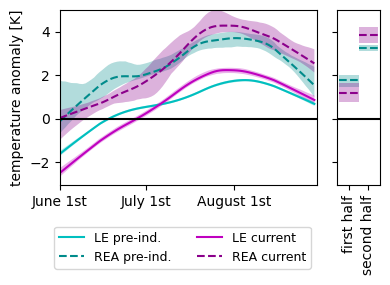

In [29]:
def plot_seasonal_cycle(axes, N_boot):

    for climate, offset in [
        ('piControl', -1),
        ('ssp370-2025', 0),
    ]:
        for type,threshold in [
            ('LE-all', 10**(-10)), 
            ('rea' , get_threshold(100)),
            ]:
            ens = ensembles[f'{climate}-{type}']
            x = np.arange(90)
            y, y_boot = ens['class'].expected_value('tas_anom', 'data', threshold, n_bootstrap=N_boot)
            y_smooth = sm.nonparametric.lowess(y,x, frac=1/3)[:,1]
            axes[0].plot(x, y_smooth, color=ens['color'], linestyle=ens['linestyle'], label=ens['label'])        

            y_boot = y_boot.reshape((-1, x.shape[0]))
            boot = np.zeros([N_boot, x.shape[0]])
            for i in range(N_boot):
                boot[i] = sm.nonparametric.lowess(y_boot[i], x, frac=1/3)[:,1]
                    #axes[0].plot(x, boot[i], color=ens['color'], linestyle=ens['linestyle'], linewidth=0.2)
            lo,hi = np.percentile(boot, [2.5,97.5], axis=0)
            axes[0].fill_between(x,lo,hi, color=ens['color'], edgecolor='none', alpha=0.3)

            if type == 'rea':
                x = np.array([0,2])
                axes[1].plot(x, [y[:45].mean()]*2, color=ens['color'], linestyle=ens['linestyle'])
                lo,hi = np.percentile(y_boot[:,:45].mean(axis=1), [2.5, 97.5])
                axes[1].fill_between(x, [lo]*2, [hi]*2, color=ens['color'], edgecolor='none', alpha=0.3)

                x = np.array([2,4])
                axes[1].plot(x, [y[45:].mean()]*2, color=ens['color'], linestyle=ens['linestyle'])
                lo,hi = np.percentile(y_boot[:,45:].mean(axis=1), [2.5, 97.5])
                axes[1].fill_between(x, [lo]*2, [hi]*2, color=ens['color'], edgecolor='none', alpha=0.3)

    axes[1].set_xticks([1,3])
    axes[1].set_xticklabels(['first half', 'second half'], rotation=90)
    axes[1].axhline(0, color='k')

    axes[0].axhline(0, color='k')
    axes[0].set_xticks([0,30,61])
    axes[0].set_xticklabels(['June 1st', 'July 1st', 'August 1st'])
    axes[0].set_ylabel('temperature anomaly [K]')
    axes[0].set_ylim(axes[0].get_ylim()[0], 5)
    axes[0].set_xlim(0,90)
    return axes

fig, axes = plt.subplots(ncols=2, figsize=(4,3), gridspec_kw=dict(width_ratios=[6,1]), sharey=True)
axes = plot_seasonal_cycle(axes, N_boot=1000)
axes[0].legend(bbox_to_anchor=(1, -0.2), fontsize=9, ncols=2)
plt.tight_layout()
savefig('seasonal_cycle')
savefig('for_paper/seasonal_cycle', also_png=False)

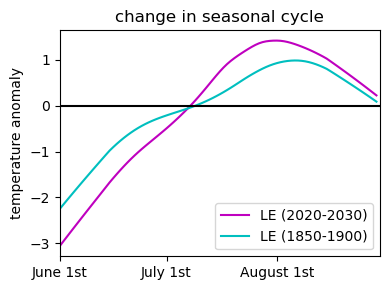

In [16]:
def plot_seasonal_cycle(ax):
    for ens_name in reference_ensemble_names:
        ens = ensembles[ens_name]
        x = np.arange(90)
        y = ens['data']['tas_anom'].mean('sim')
        y_smooth = sm.nonparametric.lowess(y,x, frac=1/3)[:,1]
        ax.plot(x, y_smooth, color=ens['color'], linestyle=ens['linestyle'], label=ens['label'])

    ax.axhline(0, color='k')
    ax.set_xticks([0,30,61])
    ax.set_xticklabels(['June 1st', 'July 1st', 'August 1st'])
    ax.set_ylabel('temperature anomaly')
    ax.set_xlim(0,90)
    return ax

fig, ax = plt.subplots(figsize=(4,3))
ax = plot_seasonal_cycle(ax)
ax.legend()
ax.set_title('change in seasonal cycle')
plt.tight_layout()

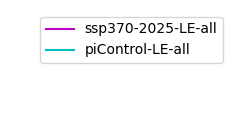

In [17]:
fig, ax = plt.subplots(figsize=(2.5,1.5))
ax.axis('off')
for ens_name in reference_ensemble_names:
    ens = ensembles[ens_name]
    ax.plot([], [], color=ens['color'], linestyle=ens['linestyle'], label=ens_name)
ax.legend()
plt.tight_layout()
savefig('reference_ensembles_legend')

In [27]:
with xr.open_mfdataset(f'external_data/from_lim/daily/TREFHT/*') as nc:
    LE_tas = nc['TREFHT'].load()
LE_tas.loc[:,'2020':'2030'].mean() - LE_tas.loc[:,'1850':'1900'].mean()

<xarray.DataArray 'TREFHT' ()>
array(1.4100342, dtype=float32)

0.8362369537353516
2.4111720754834596 1.0277412615253312
1.2096809148788452


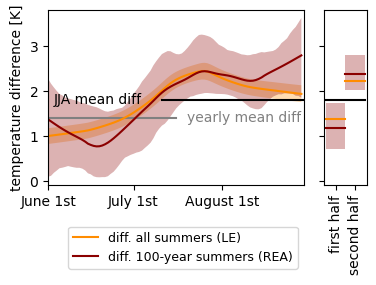

In [28]:
N_boot = 1000
fig, axes = plt.subplots(ncols=2, figsize=(4,3), gridspec_kw=dict(width_ratios=[6,1]), sharey=True)
axes[0].set_ylabel('temperature difference [K]')
axes[0].set_xlim(0,90)

mean_diff = get_reference_data('tas', 'ssp370-2025').mean() - get_reference_data('tas', 'piControl').mean()
axes[0].plot([40,90], [mean_diff]*2, color='k')
axes[1].plot([0,4], [mean_diff]*2, color='k')
t = axes[0].annotate('JJA mean diff', xy=(2, mean_diff), va='center')

mean_diff = LE_tas.loc[:,'2020':'2030'].mean() - LE_tas.loc[:,'1850':'1900'].mean()
axes[0].plot([0,45], [mean_diff]*2, color='gray')
t = axes[0].annotate('yearly mean diff', xy=(89, mean_diff), va='center', ha='right', color='gray')


x = np.arange(90)
cur = get_reference_data('tas', 'ssp370-2025')
pic = get_reference_data('tas', 'piControl')
y = cur.mean(axis=0) - pic.mean(axis=0)
axes[0].plot(x, sm.nonparametric.lowess(y,x, frac=1/3)[:,1], color='darkorange', label="diff. all summers (LE)")
boot = np.zeros([N_boot, x.shape[0]])
for i in range(N_boot):
    boot[i] = cur[np.random.choice(cur.shape[0], cur.shape[0], replace=True)].mean(axis=0).values - pic[np.random.choice(pic.shape[0], pic.shape[0], replace=True)].mean(axis=0).values
lo,up = np.percentile(boot, [2.5,97.5], axis=0)
axes[0].fill_between(x, sm.nonparametric.lowess(lo,x, frac=1/3)[:,1], sm.nonparametric.lowess(up,x, frac=1/3)[:,1], color='darkorange', edgecolor='none', alpha=0.3)

print(float(y[45:].mean() - y[:45].mean()))
#axes[0].plot([0,45], [y[:45].mean()]*2, color='darkorange', linestyle='-')
#axes[0].plot([45,89], [y[45:].mean()]*2, color='darkorange', linestyle='-')
axes[1].plot([0,2], [y[:45].mean()]*2, color='darkorange', linestyle='-')
axes[1].plot([2,4], [y[45:].mean()]*2, color='darkorange', linestyle='-')


y_smoothed = sm.nonparametric.lowess(y,x, frac=1/3)[:,1]
print(y_smoothed[54:60].mean(), y_smoothed[:7].mean())

cur, cur_boot = ensembles['ssp370-2025-rea']['class'].expected_value('tas', 'data', get_threshold(100), n_bootstrap=N_boot)
pic, pic_boot = ensembles['piControl-rea']['class'].expected_value('tas', 'data', get_threshold(100), n_bootstrap=N_boot)
y = cur - pic
axes[0].plot(x, sm.nonparametric.lowess(y,x, frac=1/3)[:,1], color='darkred', label="diff. 100-year summers (REA)")
cur_boot = cur_boot.reshape((-1, x.shape[0]))
pic_boot = pic_boot.reshape((-1, x.shape[0]))
boot = np.zeros([N_boot, x.shape[0]])
for i in range(N_boot):
    boot[i] = sm.nonparametric.lowess(cur_boot[i] - pic_boot[i], x, frac=1/3)[:,1]
lo,hi = np.percentile(boot, [2.5,97.5], axis=0)
axes[0].fill_between(x,lo,hi, color='darkred', edgecolor='none', alpha=0.3)

x = np.array([0,2])
d = cur_boot[:,:45].mean(axis=1) - pic_boot[:,:45].mean(axis=1)
axes[1].plot(x, [y[:45].mean()]*2, color='darkred', linestyle='-')
lo,hi = np.percentile(d, [2.5, 97.5])
axes[1].fill_between(x, [lo]*2, [hi]*2, color='darkred', edgecolor='none', alpha=0.3)

x = np.array([2,4])
d = cur_boot[:,45:].mean(axis=1) - pic_boot[:,45:].mean(axis=1)
axes[1].plot(x, [y[45:].mean()]*2, color='darkred', linestyle='-')
lo,hi = np.percentile(d, [2.5, 97.5])
axes[1].fill_between(x, [lo]*2, [hi]*2, color='darkred', edgecolor='none', alpha=0.3)


print(float(y[45:].mean() - y[:45].mean()))
#axes[0].plot([0,45], [y[:45].mean()]*2, color='darkred', linestyle='-')
#axes[0].plot([45,89], [y[45:].mean()]*2, color='darkred', linestyle='-')

axes[0].set_xticks([0,30,61])
axes[0].set_xticklabels(['June 1st', 'July 1st', 'August 1st'])

axes[1].set_xticks([1,3])
axes[1].set_xticklabels(['first half', 'second half'], rotation=90)

axes[0].legend(bbox_to_anchor=(1, -0.2), fontsize=9)
plt.tight_layout()
savefig('seasonal_cycle_diff')
savefig('for_paper/seasonal_cycle_diff', also_png=False)

In [45]:
jja_diff = float(get_reference_data('tas', 'ssp370-2025').mean() - get_reference_data('tas', 'piControl').mean())
year_diff = float(LE_tas.loc[:,'2020':'2030'].mean() - LE_tas.loc[:,'1850':'1900'].mean())
print(jja_diff)
print(year_diff)
print((jja_diff - year_diff) / year_diff * 100)
gmst_diff = 1.5
print((jja_diff - gmst_diff) / gmst_diff * 100)

1.8055191040039062
1.4100341796875
28.04789628603584
20.367940266927086


### Distribution is widening

In [ ]:
l = []
for ens_name in reference_ensemble_names:
    ens = ensembles[ens_name]
    y = ens['data']['tas_anom'].values.flatten()
    bs = []
    for _ in range(1000):
        bs.append(scipy.stats.norm.fit(np.random.choice(y, y.shape[0], replace=True))[1]**2)
    l.append([scipy.stats.norm.fit(y)[1]**2, bs])

In [30]:
print(l[0][0])
print(np.percentile(l[1][1], [2.5, 97.5]))
print(l[0][0] - l[1][0])
print((l[0][0] - l[1][0]) / 1.3)
print((l[0][0] - l[1][0])/l[1][0] * 100)
print((l[0][0] - l[1][0])/l[1][0] * 100 / 1.3)

8.826082830101086
[7.44777785 7.50840408]
1.3480127038976093
1.0369328491520071
18.026211056434406
13.866316197257234


In [34]:
std_cur = scipy.stats.norm.fit(ensembles['ssp370-2025-LE-all']['data']['tas_anom'].values.flatten())[1]**2
std_pic = scipy.stats.norm.fit(ensembles['piControl-LE-all']['data']['tas_anom'].values.flatten())[1]**2
(std_cur - std_pic) / std_pic * 100

18.026211056434406

In [32]:
# corrected for seasonal cycle change
l = []
for ens_name in reference_ensemble_names:
    ens = ensembles[ens_name]
    y = ens['data']['tas_seas_anom'].values.flatten()
    bs = []
    for _ in range(1000):
        bs.append(scipy.stats.norm.fit(np.random.choice(y, y.shape[0], replace=True))[1]**2)
    l.append([scipy.stats.norm.fit(y)[1]**2, bs])

In [33]:
print(l[0][0])
print(np.percentile(l[1][1], [2.5, 97.5]))
print(l[0][0] - l[1][0])
print((l[0][0] - l[1][0]) / 1.3)
print((l[0][0] - l[1][0])/l[1][0] * 100)
print((l[0][0] - l[1][0])/l[1][0] * 100 / 1.3)

6.976207305575599
[6.65743465 6.70799029]
0.29350753966235743
0.2257750305095057
4.392050368018402
3.378500283091078


In [35]:
std_cur = scipy.stats.norm.fit(ensembles['ssp370-2025-LE-all']['data']['tas_seas_anom'].values.flatten())[1]**2
std_pic = scipy.stats.norm.fit(ensembles['piControl-LE-all']['data']['tas_seas_anom'].values.flatten())[1]**2
(std_cur - std_pic) / std_pic * 100

4.392050368018402

In [ ]:
l = []
for climate in climates:
    ens_name = f'{climate}-rea'
    ens = ensembles[ens_name]
    bs = []
    for _ in range(100):
        y, bs_ = ens['class'].expected_value('tas_anom', 'data', get_threshold(100), n_bootstrap=100)
        bs.append(scipy.stats.norm.fit(bs_)[1])
    bs = np.array(bs)
    l.append([bs.mean(), bs])

In [ ]:
print(l[0][0])
print(np.percentile(l[1][1], [2.5, 97.5]))
print(l[0][0] - l[1][0])
print((l[0][0] - l[1][0]) / 1.3)
print((l[0][0] - l[1][0])/l[1][0] * 100)
print((l[0][0] - l[1][0])/l[1][0] * 100 / 1.3)

1.712390767242897
[1.23262823 1.27283564]
0.463856936028906
0.35681302771454304
37.152131919235416
28.578563014796472


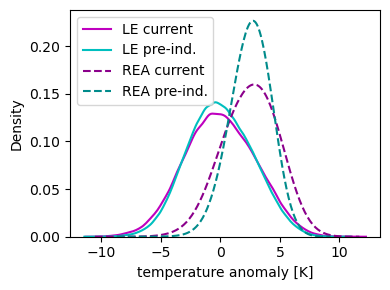

In [33]:
fig, ax = plt.subplots(figsize=(4,3))

for ens_name in reference_ensemble_names:
    ens = ensembles[ens_name]
    sns.kdeplot(ens['data']['tas_anom'].values.flatten(), ax=ax, color=ens['color'], linestyle=ens['linestyle'], label=ens['label'])
for climate in climates:
    ens_name = f'{climate}-rea'
    ens = ensembles[ens_name]
    y, bs = ens['class'].expected_value('tas_anom', 'data', get_threshold(100), n_bootstrap=1000)
    sns.kdeplot(bs, ax=ax, color=ens['color'], linestyle=ens['linestyle'], label=ens['label'], bw_method=1)

ax.set_xlabel('temperature anomaly [K]')

ax.legend()
plt.tight_layout()
savefig('distribution_widening')
savefig('for_paper/distribution_widening', also_png=False)

## land interaction

### additional data and indicators

In [42]:
for ens_name, ens  in ensembles.items():
    if 'hfss' in ens['data'] and 'hfls' in ens['data']:
        ens['data']['hfss_ratio'] = ens['data']['hfss'] / (ens['data']['hfss'] + ens['data']['hfls'])
        ens['data']['bowen_ratio'] = ens['data']['hfss'] / ens['data']['hfls']
        ens['data']['bowen>1'] = ens['data']['bowen_ratio'] > 1
        ens['data']['EF'] = ens['data']['hfls'] / (ens['data']['hfss'] + ens['data']['hfls'])
    if 'pr' in ens['data']:
        ens['data']['pr_cum'] = ens['data']['pr'].cumsum(axis=1)
        ens['stats']['pr_sum'] = ens['data']['pr'].sum('time') 
        if ens['data']['pr_cum'].max() < 10:
            ens['data']['pr_cum'] *= 1000
            ens['stats']['pr_sum'] *= 1000

### stats

In [43]:
for climate in climates:
    e,l = ensembles[f'{climate}-LE-all']['class'].expected_value('pr_sum', 'stats', -10**10, 1000)
    lo,hi = np.percentile(l, [0.025, 97.5])
    print(f"{climate}:\t {e:.2f} ({lo:.2f} - {hi:.2f})")

ssp370-2025:	 178.88 (175.30 - 181.06)
piControl:	 194.59 (193.02 - 195.66)


In [44]:
(179 - 195) / 195

-0.08205128205128205

In [45]:
pic = ensembles['piControl-LE-all']['data']['pr'].mean() 
cur = ensembles['ssp370-2025-LE-all']['data']['pr'].mean()
(cur - pic ) / pic

<xarray.DataArray 'PRECT' ()>
array(-0.08071724, dtype=float32)

### timing bowen

ssp370-2025-LE-moist 52.0
ssp370-2025-LE-moist 46.0
ssp370-2025-rea345 45.0
ssp370-2025-rea-dry 38.0
piControl-LE-moist 63.0
piControl-LE-moist 49.0
piControl-rea345 50.0


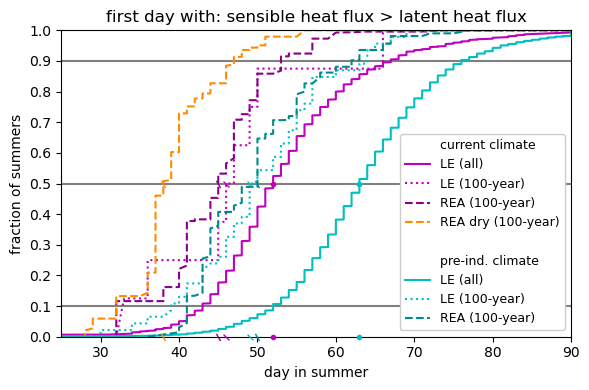

In [46]:
def weighted_ecdf(data, weights):
    """Calculate weighted Empirical Cumulative Distribution Function"""
    data, weights = np.array(data), np.array(weights)
    idx = np.argsort(data)
    data, weights = data[idx], weights[idx]
    ecdf = np.cumsum(weights) / np.sum(weights)
    return data, ecdf

fig,ax = plt.subplots(nrows=1, figsize=(6,4))
threshold = get_threshold(100)
for i,climate,climate_name in [
    (0, 'ssp370-2025', 'current'),
    (1, 'piControl', 'pre-ind.')
]:
    if i == 1:
        ax.plot([], [], color='w', label=f" ")
    ax.plot([], [], color='w', label=f"{climate_name} climate")
    for type in [ 'LE-moist', 'rea345', 'rea-dry']:
        ens_name = f'{climate}-{type}'
        if ens_name in ensembles.keys():
            ens = ensembles[ens_name]
            tas = ens['data']['tas_anom'].mean('time')
            bowen = ens['data']['bowen_ratio']
            z = np.array([])
            for sim in bowen.sim.values:
                if bowen.loc[sim].max() > 1:
                    z = np.append(z, np.where((bowen.loc[sim] > 1) == True)[0][0])
                else:
                    z = np.append(z, 90)

            if type == 'rea345' or type == 'rea-dry':
                weight = ens['class'].adjust_weights_for_threshold(threshold)
                x,y = weighted_ecdf(z, weight)
                print(ens_name, x[y>=0.5][0])
                ax.scatter([x[y>=0.5][0]]*2, [0,0.5], color=ens['color'], marker=(2,0,30), clip_on=False, zorder=10)
                expect = weighted_expected_value(tas, weight, threshold, z)

                if type == 'rea345':
                    label = f"REA (100-year)"
                if type == 'rea-dry':
                    label = f"REA dry (100-year)"

                ax.plot(x, y, color=ens['color'], linestyle=ens['linestyle'], label=label)
                ax.plot([expect]*2, [1.1, 1.2], color=ens['color'], linestyle=ens['linestyle'])

            if type == 'LE-moist':
                x,y = weighted_ecdf(z, z*0+1)
                print(ens_name, x[y>=0.5][0])
                ax.scatter([x[y>=0.5][0]]*2, [0,0.5], color=ens['color'], marker='.', clip_on=False, zorder=10)
                expect = weighted_expected_value(tas, z*0+1, -90, z)
                ax.plot(x, y, color=ens['color'], linestyle=ens['linestyle'], label=f"LE (all)")
                ax.plot([expect]*2, [1.1, 1.2], color=ens['color'], linestyle=ens['linestyle'])

                weight = ens['class'].adjust_weights_for_threshold(threshold)
                x,y = weighted_ecdf(z, weight)
                ax.scatter([x[y>=0.5][0]]*2, [0,0.5], color=ens['color'], marker=(2,0,45), clip_on=False, zorder=10)
                print(ens_name, x[y>=0.5][0])
                expect = weighted_expected_value(tas, weight, threshold, z)
                ax.plot(x, y, color=ens['color'], linestyle=':', label=f"LE (100-year)")
                ax.plot([expect]*2, [1.1, 1.2], color=ens['color'], linestyle=':')
            

ax.plot([expect]*2, [1.1, 1.2], color=ens['color'], linestyle=ens['linestyle'])

ax.set_title('first day with: sensible heat flux > latent heat flux')
ax.set_yticks(np.arange(0,1.2,0.1))
ax.set_ylim(0,1)
ax.set_xlim(25,90)
ax.set_xlabel('day in summer')
ax.set_ylabel('fraction of summers')
ax.legend(ncols=1, fontsize=9, loc='lower right', framealpha=1.0)#, bbox_to_anchor=(0.8,0.8))
for q in [0.1,0.5,0.9]:
    ax.axhline(q, color='gray', zorder=0)
plt.tight_layout()
savefig('evolution/bowen_flip')
savefig('for_paper/bowen_flip', also_png=False)

### temporal evolution through the season

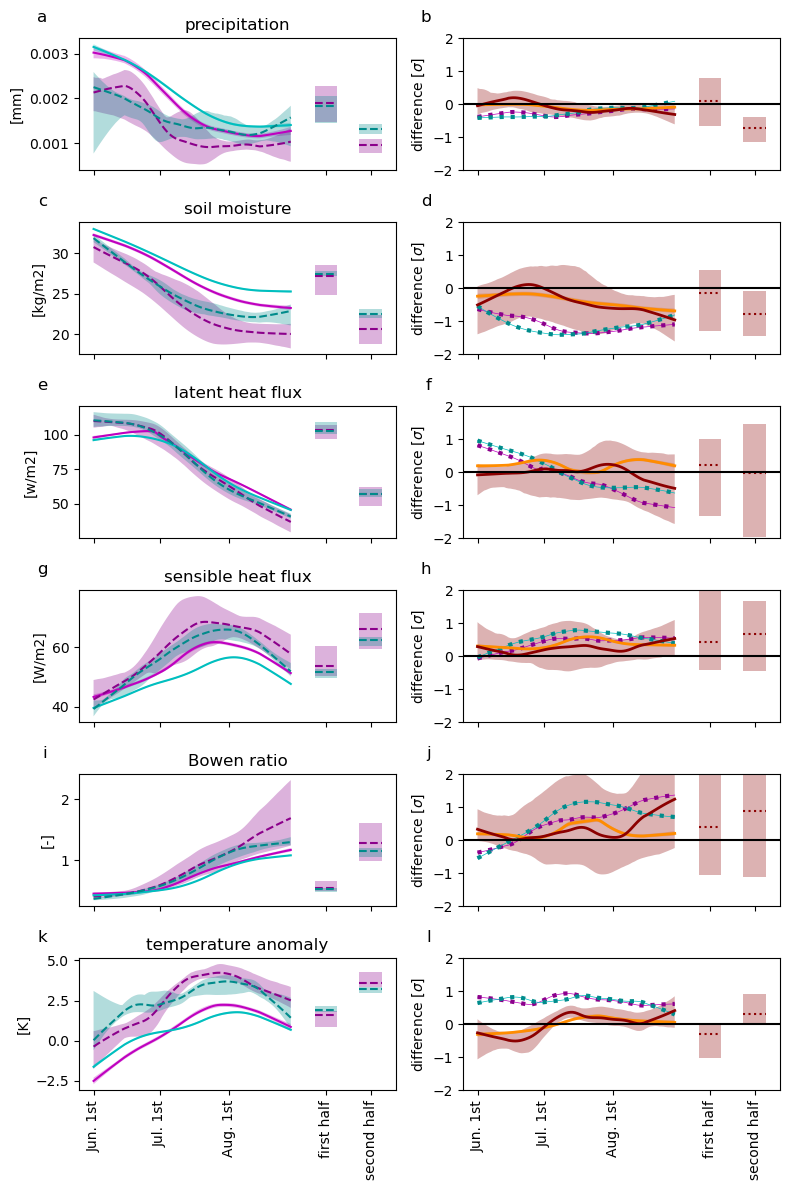

In [48]:
rt = 100
N_boot = 1000
fig,axes = plt.subplots(nrows=6, ncols=2, sharey=False, sharex=True, figsize=(8,12))
x = np.arange(90)
for ax,letter in zip(axes.flatten(), string.ascii_lowercase):
    t = ax.annotate(letter, xy=(-0.1,1.1), xycoords='axes fraction', va='bottom', ha='right', fontsize=12)
    t.set_bbox(dict(facecolor='w', edgecolor='none'))

for r,var,var_label,unit in [
    (0 ,'pr', 'precipitation', '[mm]'),
    (1 ,'mrsos', 'soil moisture', '[kg/m2]'),
    (2 ,'hfls', 'latent heat flux', '[w/m2]'),
    (3 ,'hfss', 'sensible heat flux', '[W/m2]'),
    (4 ,'bowen_ratio', 'Bowen ratio', '[-]'),
    (5 ,'tas_anom', 'temperature anomaly', '[K]'),
    ]:

    for climate in climates:
        for type,threshold in [
            ('LE-moist', 10**(-10)), 
            ('rea345' , get_threshold(100)),
            ]:
            ens = ensembles[f'{climate}-{type}']
            x = np.arange(90)
            y, y_boot = ens['class'].expected_value(var, 'data', threshold, n_bootstrap=N_boot)
            y_smooth = sm.nonparametric.lowess(y,x, frac=1/3)[:,1]
            axes[r,0].plot(x, y_smooth, color=ens['color'], linestyle=ens['linestyle'], label=ens['label'])        

            if type == 'LE-moist':
                ref = sm.nonparametric.lowess(y,x, frac=1/3)[:,1]
                ref_std = ensembles[f"{climate}-LE-moist"]['data'][var].std('sim')
                ref_std_smooth = sm.nonparametric.lowess(ref_std, x, frac=0.3)[:,1]
                ref_std_first = ensembles[f"{climate}-LE-moist"]['data'][var][:,:45].mean('time').std('sim')
                ref_std_second = ensembles[f"{climate}-LE-moist"]['data'][var][:,45:].mean('time').std('sim')

            y_boot = y_boot.reshape((-1, x.shape[0]))
            boot = np.zeros([N_boot, x.shape[0]])
            for i in range(N_boot):
                boot[i] = sm.nonparametric.lowess(y_boot[i], x, frac=1/3)[:,1]
                    #axes[r,0].plot(x, boot[i], color=ens['color'], linestyle=ens['linestyle'], linewidth=0.2)
            lo,hi = np.percentile(boot, [2.5,97.5], axis=0)
            axes[r,0].fill_between(x,lo,hi, color=ens['color'], edgecolor='none', alpha=0.3)

            if type == 'rea345':
                x_ = np.array([100,110])
                axes[r,0].plot(x_, [y[:45].mean()]*2, color=ens['color'], linestyle=ens['linestyle'])
                lo,hi = np.percentile(y_boot[:,:45].mean(axis=1), [2.5, 97.5])
                axes[r,0].fill_between(x_, [lo]*2, [hi]*2, color=ens['color'], edgecolor='none', alpha=0.3)

                x_ = np.array([120,130])
                axes[r,0].plot(x_, [y[45:].mean()]*2, color=ens['color'], linestyle=ens['linestyle'])
                lo,hi = np.percentile(y_boot[:,45:].mean(axis=1), [2.5, 97.5])
                axes[r,0].fill_between(x_, [lo]*2, [hi]*2, color=ens['color'], edgecolor='none', alpha=0.3)

                axes[r,1].plot(x, (y_smooth - ref) / ref_std_smooth, color=ensembles[f"{climate}-LE-moist"]['color'], linewidth=0.5, linestyle='-')
                axes[r,1].plot(x, (y_smooth - ref) / ref_std_smooth, color=ens['color'], linewidth=3, linestyle=':')

    # orange
    cur, cur_boot = ensembles[f"ssp370-2025-LE-moist"]['class'].expected_value(var, 'data', -10**10, N_boot)
    pic, pic_boot = ensembles[f"piControl-LE-moist"]['class'].expected_value(var, 'data', -10**10, N_boot)
    y = (cur - pic) / ref_std_smooth
    y_smooth = sm.nonparametric.lowess(y, x, frac=1/3)[:,1]
    axes[r,1].plot(x, y_smooth, color='darkorange', linewidth=2, linestyle='-')  

    cur_boot = cur_boot.reshape((-1, x.shape[0]))
    pic_boot = pic_boot.reshape((-1, x.shape[0]))
    boot = np.zeros([N_boot, x.shape[0]])
    for i in range(N_boot):
        boot[i] = sm.nonparametric.lowess((cur_boot[i] - pic_boot[i])  / ref_std_smooth, x, frac=1/3)[:,1]
    lo,hi = np.percentile(boot, [2.5,97.5], axis=0)
    axes[r,1].fill_between(x,lo,hi, color='darkorange', edgecolor='none', alpha=0.3)

    # red
    cur, cur_boot = ensembles[f"ssp370-2025-rea345"]['class'].expected_value(var, 'data', get_threshold(100), N_boot)
    pic, pic_boot = ensembles[f"piControl-rea345"]['class'].expected_value(var, 'data', get_threshold(100), N_boot)
    y = (cur - pic) / ref_std_smooth
    y_smooth = sm.nonparametric.lowess(y, x, frac=1/3)[:,1]
    axes[r,1].plot(x, y_smooth, color='darkred', linewidth=2, linestyle='-')  

    cur_boot = cur_boot.reshape((-1, x.shape[0]))
    pic_boot = pic_boot.reshape((-1, x.shape[0]))
    boot = np.zeros([N_boot, x.shape[0]])
    d_first = np.zeros([N_boot])
    d_second = np.zeros([N_boot])
    for i in range(N_boot):
        boot[i] = sm.nonparametric.lowess((cur_boot[i] - pic_boot[i])  / ref_std_smooth, x, frac=1/3)[:,1]
        d_first[i] = ((cur_boot[i][:45].mean() - pic_boot[i][:45].mean())  / ref_std_first)
        d_second[i] = ((cur_boot[i][45:].mean() - pic_boot[i][45:].mean()) / ref_std_second)
    lo,hi = np.percentile(boot, [2.5,97.5], axis=0)
    axes[r,1].fill_between(x,lo,hi, color='darkred', edgecolor='none', alpha=0.3)

    x_ = np.array([100,110])
    d = (cur[:45].mean() - pic[:45].mean()) / ref_std_first
    axes[r,1].plot(x_, [d]*2, color='darkred', linestyle=':')
    lo,hi = np.percentile(d_first, [2.5, 97.5])
    axes[r,1].fill_between(x_, [lo]*2, [hi]*2, color='darkred', edgecolor='none', alpha=0.3)

    x_ = np.array([120,130])
    d = (cur[45:].mean() - pic[45:].mean()) / ref_std_second
    axes[r,1].plot(x_, [d]*2, color='darkred', linestyle=':')
    lo,hi = np.percentile(d_second, [2.5, 97.5])
    axes[r,1].fill_between(x_, [lo]*2, [hi]*2, color='darkred', edgecolor='none', alpha=0.3)

    axes[r,1].axhline(0, color='k')
    axes[r,1].set_ylim(-2,2)
    axes[r,1].set_ylabel('difference [$\sigma$]')

    axes[r,0].set_title(var_label)
    axes[r,0].set_ylabel(unit)
    for ax in axes[r]:
        ax.set_xticks([0,30,61,105,125])
        ax.set_xticklabels(['Jun. 1st', 'Jul. 1st', 'Aug. 1st', "first half", "second half"], rotation=90)


plt.tight_layout()
savefig(f'evolution/all_{rt}')
savefig('for_paper/evolution_all_100', also_png=False)

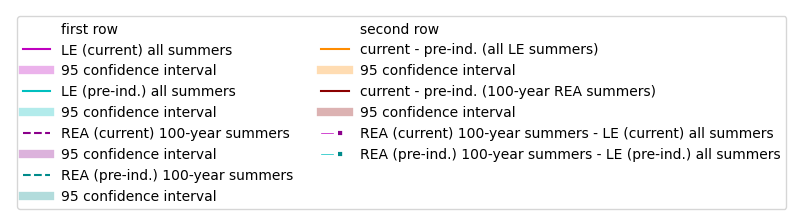

In [ ]:
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

fig, ax = plt.subplots(figsize=(9,1.5))
ax.axis('off')

lines, labels = [], []
lines.append(Line2D([], [], color='w', linestyle='-'))
labels.append(f"first row")
for climate in climates:
    ens = ensembles[f'{climate}-LE-moist']
    lines.append(Line2D([], [], color=ens['color'], linestyle=ens['linestyle']))
    labels.append(f"{ens['label']} all summers")
    lines.append(Line2D([], [], color=ens['color'], lw=6, alpha=0.3))
    labels.append(f"95 confidence interval")
for climate in climates:
    ens = ensembles[f"{climate}-rea345"]
    lines.append(Line2D([], [], color=ens['color'], linestyle=ens['linestyle']))
    labels.append(f"{ens['label']} 100-year summers")
    lines.append(Line2D([], [], color=ens['color'], lw=6, alpha=0.3))
    labels.append(f"95 confidence interval")

lines.append(Line2D([], [], color='w', linestyle='-'))
labels.append(f"second row")
lines.append(Line2D([], [], color='darkorange', linestyle='-'))
labels.append(f"current - pre-ind. (all LE summers)")
lines.append(Line2D([], [], color='darkorange', lw=6, alpha=0.3))
labels.append(f"95 confidence interval")
lines.append(Line2D([], [], color='darkred', linestyle='-'))
labels.append(f"current - pre-ind. (100-year REA summers)")
lines.append(Line2D([], [], color='darkred', lw=6, alpha=0.3))
labels.append(f"95 confidence interval")

for climate in climates:
    ens = ensembles[f"{climate}-rea345"]
    labels.append(f"{ens['label']} 100-year summers - {ensembles[f'{climate}-LE-moist']['label']} all summers")

    l1 = Line2D([], [], color=ensembles[f"{climate}-LE-moist"]['color'], linewidth=0.5, linestyle='-')
    l2 = Line2D([], [], color=ens['color'], linewidth=3, linestyle=':')
    lines.append((l1, l2))

for _ in range(2):
    lines.append(Line2D([], [], color='w', linestyle='-'))
    labels.append(f"")

ax.legend(lines, labels, handler_map={tuple: HandlerTuple(ndivide=None)}, loc='upper left', ncols=2, bbox_to_anchor=(0,1))
plt.tight_layout()
savefig(f'evolution/all_legend', bbox_inches='tight')

In [106]:
cur = float(ensembles['ssp370-2025-rea345']['class'].expected_value('pr_sum', 'stats', get_threshold(100)))
pic = float(ensembles['piControl-rea345']['class'].expected_value('pr_sum', 'stats', get_threshold(100)))
print(cur)
print(pic)
print((cur - pic) / pic * 100)

128.23627529461191
141.6478451182489
-9.468248396183434


In [107]:
cur = float(ensembles['ssp370-2025-rea345']['class'].expected_value('bowen_ratio', 'data', get_threshold(100)).max('time'))
pic = float(ensembles['piControl-rea345']['class'].expected_value('bowen_ratio', 'data', get_threshold(100)).max('time'))
print(cur)
print(pic)
print((cur - pic) / pic * 100)

1.698311448097229
1.3865729570388794
22.48266053912434


In [108]:
cur = float(ensembles['ssp370-2025-LE-moist']['stats']['pr_sum'].mean())
pic = float(ensembles['piControl-LE-moist']['stats']['pr_sum'].mean())
print(cur)
print(pic)
print((cur - pic) / pic * 100)

178.88246154785156
194.58917236328125
-8.0717290816709


In [110]:
cur = float(ensembles['ssp370-2025-LE-moist']['data']['mrsos'][:,-1].mean())
pic = float(ensembles['piControl-LE-moist']['data']['mrsos'][:,-1].mean())
print(cur)
print(pic)
print((cur - pic) / pic * 100)

24.647939682006836
26.644702911376953
-7.494034502886217


### surviving start conditions in REA

In [58]:
mrsos0 = ensembles['ssp370-2025-initial']['data']['mrsos'][:,0]
dry_start_id = np.argsort(mrsos0)[:10]
dry_start_id

<xarray.DataArray 'mrsos' (sim: 10)>
array([ 57, 114,  25,  45,  52, 120,  32,  20, 108,  93])
Coordinates:
  * sim      (sim) <U11 'ens001_2024' 'ens001_2025' ... 'ens004_2024'
    time     datetime64[ns] 2025-06-01

In [59]:
ens = ensembles['ssp370-2025-rea345']
ens['data']['start_id'] = np.array([int(s.split('/')[0].split('_')[-1]) for s in ens['data']['tas'].sim.values])

In [60]:
ens = ensembles['ssp370-2025-rea-dry']
fake_start_id = np.array([int(s.split('.')[1]) for s in ens['data']['tas'].sim.values])
ens['data']['start_id'] = np.array([int(s.split('.')[1]) for s in ens['data']['tas'].sim.values]) * 0
for i,real_start_id in enumerate(dry_start_id):
    ens['data']['start_id'][(fake_start_id >= i*10) & (fake_start_id <= (i+1)*10)] = real_start_id

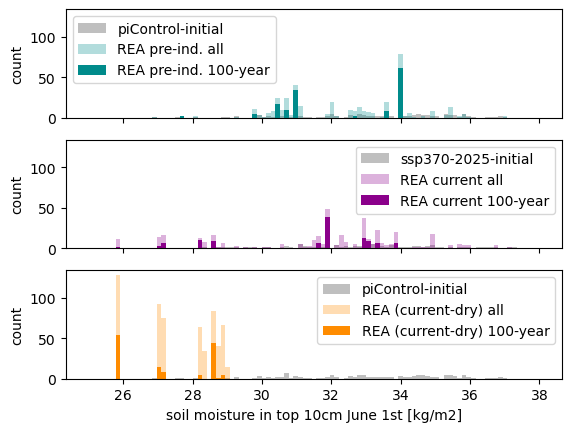

In [53]:
fig,axes = plt.subplots(nrows=3, sharex=True, sharey=True)
bins = np.linspace(25,38,100)
for r,ens_name in enumerate(['piControl-rea345', 'ssp370-2025-rea345', 'ssp370-2025-rea-dry']):
    ens = ensembles[ens_name]
    events = np.where(ens['data']['tas_anom'].mean('time') > get_threshold(100))[0]
    axes[r].hist(ensembles[f"{ens['climate']}-initial"]['data']['mrsos'][:,0], bins=bins, alpha=0.5, label=f"{ens['climate']}-initial", color='gray')
    axes[r].hist(ens['data']['mrsos'][:,0], bins=bins, alpha=0.3, color=ens['color'], label=f"{ens['label']} all")
    axes[r].hist(ens['data']['mrsos'][events,0], bins=bins, color=ens['color'], label=f"{ens['label']} 100-year")
    axes[r].legend()
    axes[r].set_ylabel('count')
axes[-1].set_xlabel('soil moisture in top 10cm June 1st [kg/m2]')
savefig(f'surviving_start_conditions_100')

In [78]:
sm_thresh = 29 

In [79]:
for ens_name in ['piControl-rea345', 'ssp370-2025-rea345', 'ssp370-2025-rea-dry']:
    ens = ensembles[ens_name]
    y = ens['data']['mrsos'][:,0]
    selection = (y>=0) & (y<=sm_thresh)
    p = weighted_probability(
        tas = ens['data']['tas_anom'].mean('time')[selection],
        weight = ens['data']['weight'][selection],
        threshold = get_threshold(100)
    )

    l = []
    for e in np.unique(ens['class']._ens_i):
        w = ens['class']._weight[(ens['class']._ens_i==e) & (y>=0) & (y<=sm_thresh)].copy()
        w /= w.sum()
        l.append(w)
    weight = xr.concat(l, dim='sim').values

    p2 = weighted_probability(
        tas = ens['data']['tas_anom'].mean('time')[selection],
        weight = weight,
        threshold = get_threshold(100)
    )


    print(ens_name, p, p2)

piControl-rea345 0.018503498286008835 0.5
ssp370-2025-rea345 0.04858260974287987 0.04824726656079292
ssp370-2025-rea-dry 0.04037072882056236 0.16835613548755646


In [80]:
for ens_name in ['piControl-LE-all', 'ssp370-2025-LE-all']:
    ens = ensembles[ens_name]
    y = ens['data']['mrsos'][:,0]
    y_all = y[(y>=0) & (y<=sm_thresh)]
    y_100 = y[(y>=0) & (y<=sm_thresh) & (ens['data']['tas_anom'].mean('time') > get_threshold(100))]
    print(ens_name, y_100.shape[0]/y_all.shape[0])

piControl-LE-all 0.05027932960893855
ssp370-2025-LE-all 0.0410958904109589


In [82]:
for ens_name in ['piControl-LE-all', 'ssp370-2025-LE-all']:
    ens = ensembles[ens_name]
    y = ens['data']['mrsos'][:,0]
    y_all = y[(y>=0) & (y<=sm_thresh)]
    print(ens_name, y_all.shape[0]/y.shape[0])
    print(ens_name, y.shape[0]/y_all.shape[0])

piControl-LE-all 0.038997821350762525
piControl-LE-all 25.64245810055866
ssp370-2025-LE-all 0.07373737373737374
ssp370-2025-LE-all 13.561643835616438


### temporal evolution in dry ensembles

In [64]:
def get_evolution(ens, var, x, threshold, N_boot):
    y, y_boot = ens['class'].expected_value(var, 'data', threshold, N_boot)
    y_smoothed = sm.nonparametric.lowess(y, x_axis, frac=0.3)[:,1]
        
    y_boot = y_boot.reshape((-1, x.shape[0]))
    boot = np.zeros([N_boot, x.shape[0]])
    for i in range(N_boot):
        boot[i] = sm.nonparametric.lowess(y_boot[i], x, frac=1/3)[:,1]
            #ax.plot(x, boot[i], color=ens['color'], linestyle=ens['linestyle'], linewidth=0.2)
    lo,hi = np.percentile(boot, [2.5,97.5], axis=0)

    return y_smoothed, lo, hi

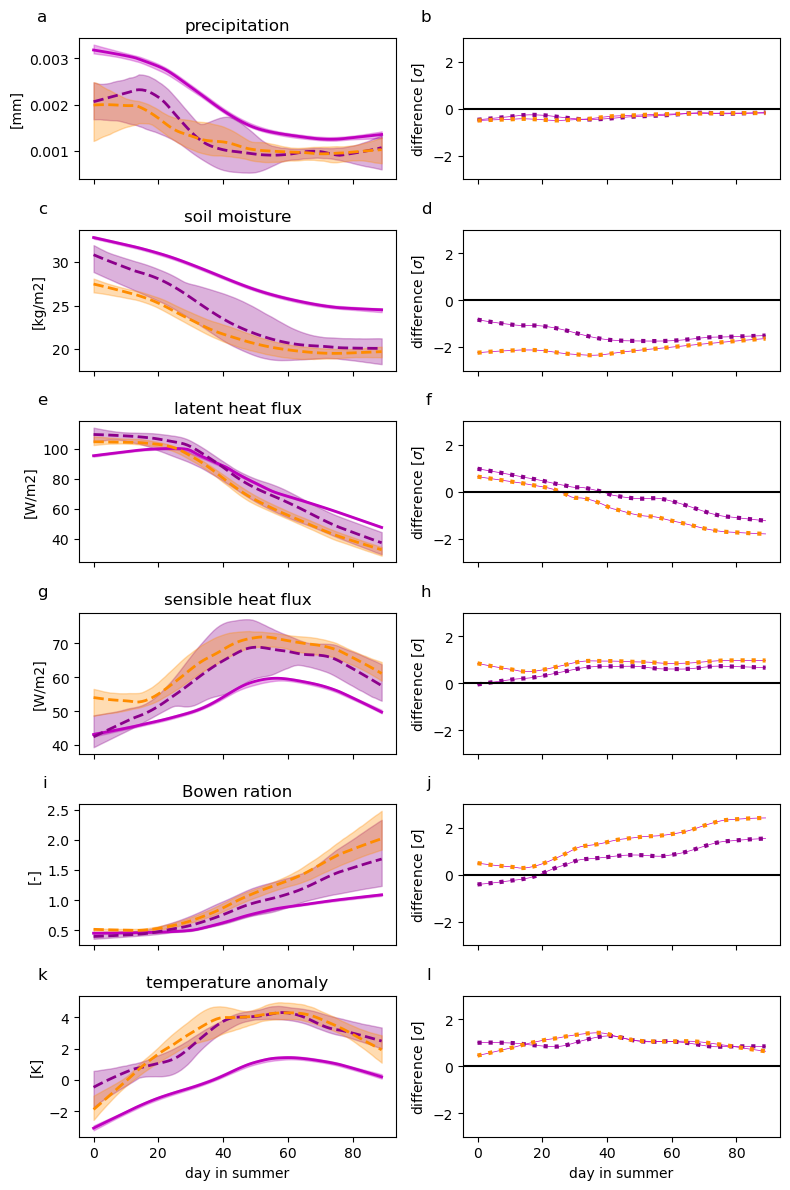

In [265]:
N_boot = 1000
climate = 'ssp370-2025'
fig,axes = plt.subplots(nrows=6, ncols=2, sharey=False, sharex=True, figsize=(8,12))
x_axis = np.arange(90)
for ax,letter in zip(axes.flatten(), string.ascii_lowercase):
    t = ax.annotate(letter, xy=(-0.1,1.1), xycoords='axes fraction', va='bottom', ha='right', fontsize=12)
    t.set_bbox(dict(facecolor='w', edgecolor='none'))
for ax in axes[-1,:]:
    ax.set_xlabel('day in summer')
for r,var,var_label, unit in [
    (0 ,'pr', 'precipitation', '[mm]'),
    (1 ,'mrsos', 'soil moisture', '[kg/m2]'),
    (2 ,'hfls', 'latent heat flux', '[W/m2]'),
    (3 ,'hfss', 'sensible heat flux', '[W/m2]'),
    (4 ,'bowen_ratio', 'Bowen ration', '[-]'),
    (5 ,'tas_anom', 'temperature anomaly', '[K]'),
    ]:

    ens = ensembles[f"{climate}-LE-moist"]
    ref, hi, lo = get_evolution(ens, var, x_axis, -10**10, N_boot)
    axes[r,0].plot(x_axis, ref, color=ens['color'], linewidth=2, linestyle=ens['linestyle'])
    axes[r,0].fill_between(x_axis, hi, lo, color=ens['color'], alpha=0.3)

    ref_std = ensembles[f"{climate}-LE-moist"]['data'][var].std('sim')
    ref_std_smoothed = sm.nonparametric.lowess(ref_std, x_axis, frac=0.3)[:,1]

    for ens_name in [f"{climate}-rea345", f"{climate}-rea-dry"]:
        ens = ensembles[ens_name]
        y_smoothed, hi, lo = get_evolution(ens, var, x_axis, get_threshold(100), N_boot)
        y = ens['class'].expected_value(var, 'data', get_threshold(100))
        axes[r,0].plot(x_axis, y_smoothed, color=ens['color'], linewidth=2, linestyle=ens['linestyle'])
        axes[r,0].fill_between(x_axis, hi, lo, color=ens['color'], alpha=0.3)

        y = ens['class'].expected_value(var, 'data', get_threshold(100))
        y_smoothed = sm.nonparametric.lowess(y, x_axis, frac=0.3)[:,1]
        axes[r,1].plot(x_axis, (y_smoothed - ref) / ref_std_smoothed, color=ensembles[f"{climate}-LE-moist"]['color'], linewidth=0.5, linestyle='-')
        axes[r,1].plot(x_axis, (y_smoothed - ref) / ref_std_smoothed, color=ens['color'], linewidth=3, linestyle=':')

    axes[r,1].axhline(0, color='k')
    axes[r,1].set_ylim(-3,3)
    axes[r,0].set_title(var_label)
    axes[r,0].set_ylabel(unit)
    axes[r,1].set_ylabel('difference [$\sigma$]')

plt.tight_layout()
savefig(f'evolution/dry_{rt}')
savefig('for_paper/evolution_dry_100', also_png=False)

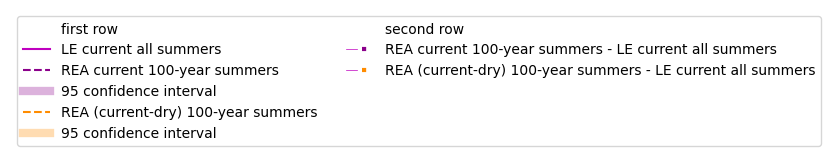

In [52]:
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerTuple

fig, ax = plt.subplots(figsize=(9,1.5))
ax.axis('off')

climate = 'ssp370-2025'
lines, labels = [], []
lines.append(Line2D([], [], color='w', linestyle='-'))
labels.append(f"first row")

ens = ensembles[f'{climate}-LE-moist']
lines.append(Line2D([], [], color=ens['color'], linestyle=ens['linestyle']))
labels.append(f"{ens['label']} all summers")

ens = ensembles[f"{climate}-rea345"]
lines.append(Line2D([], [], color=ens['color'], linestyle=ens['linestyle']))
labels.append(f"{ens['label']} 100-year summers")
lines.append(Line2D([], [], color=ens['color'], lw=6, alpha=0.3))
labels.append(f"95 confidence interval")

ens = ensembles[f"{climate}-rea-dry"]
lines.append(Line2D([], [], color=ens['color'], linestyle=ens['linestyle']))
labels.append(f"{ens['label']} 100-year summers")
lines.append(Line2D([], [], color=ens['color'], lw=6, alpha=0.3))
labels.append(f"95 confidence interval")

lines.append(Line2D([], [], color='w', linestyle='-'))
labels.append(f"second row")
ens = ensembles[f"{climate}-rea345"]
labels.append(f"{ens['label']} 100-year summers - {ensembles[f'{climate}-LE-moist']['label']} all summers")
l1 = Line2D([], [], color=ensembles[f"{climate}-LE-moist"]['color'], linewidth=0.5, linestyle='-')
l2 = Line2D([], [], color=ens['color'], linewidth=3, linestyle=':')
lines.append((l1, l2))

ens = ensembles[f"{climate}-rea-dry"]
labels.append(f"{ens['label']} 100-year summers - {ensembles[f'{climate}-LE-moist']['label']} all summers")
l1 = Line2D([], [], color=ensembles[f"{climate}-LE-moist"]['color'], linewidth=0.5, linestyle='-')
l2 = Line2D([], [], color=ens['color'], linewidth=3, linestyle=':')
lines.append((l1, l2))

lines.append(Line2D([], [], color='w', linestyle='-'))
labels.append(f"")
lines.append(Line2D([], [], color='w', linestyle='-'))
labels.append(f"")

ax.legend(lines, labels, handler_map={tuple: HandlerTuple(ndivide=None)}, loc='upper left', ncols=2, bbox_to_anchor=(0,1))
plt.tight_layout()
savefig(f'evolution/dry_legend', bbox_inches='tight')
savefig('for_paper/dry_legend', also_png=False)

## rank day anomalies

In [47]:
for climate in climates:
    for type in ['LE-all','rea', 'initial', 'rea-dry']:
        ens_name = f'{climate}-{type}'
        if ens_name in ensembles.keys():
            ens = ensembles[ens_name]
            T = ens['data'][f'tas_anom']
            T_sorted = xr.concat([
                T.loc[sim].sortby(T.loc[sim]).assign_coords(time=T.time) for sim in T.sim    
            ], dim = 'sim')
            ens['stats'][f'tas_anom_sorted'] = T_sorted
            ens['stats']['RDM'] = T_sorted.mean('sim')
            if type == 'LE-all':
                ens['stats']['RDA'] = T_sorted - ens['stats']['RDM']
            if type == 'rea' or type == 'initial' or type == 'rea-dry':
                ens['stats']['RDA'] = T_sorted - ensembles[f'{climate}-LE-all']['stats']['RDM'].values
                
            ens['stats'][f'RDA_cold30_anom'] = ens['stats']['RDA'][:,:30].sum('time') / 90
            ens['stats'][f'XFcold30_anom'] = ens['class'].expected_value(f'RDA_cold30_anom', 'stats', get_threshold(100)) / (ens['class'].expected_value(f'tas_mean_anom', 'stats', get_threshold(100)) - ensembles[f"{climate}-LE-all"]['stats'][f'tas_mean_anom'].mean())

            ens['stats'][f'RDA_warm30_anom'] = ens['stats']['RDA'][:,-30:].sum('time') / 90
            ens['stats'][f'XFwarm30_anom'] = ens['class'].expected_value(f'RDA_warm30_anom', 'stats', get_threshold(100)) / (ens['class'].expected_value(f'tas_mean_anom', 'stats', get_threshold(100)) - ensembles[f"{climate}-LE-all"]['stats'][f'tas_mean_anom'].mean())

In [48]:
tab = pd.DataFrame(index=climates+['diff'], columns=['rea', 'LE-all'])
for climate in climates:
    for type in ['LE-all','rea']:
        ens_name = f'{climate}-{type}'
        ens = ensembles[f'{climate}-{type}']
        tab.loc[climate,type] = np.round(ens['stats'][f'XFwarm30_anom'].values, 2)

In [49]:
tab['diff'] = tab['rea'] - tab['LE-all']
tab.loc['diff',:] = tab.loc['ssp370-2025'] - tab.loc['piControl']
tab = tab.round(1)

In [50]:
tab

,rea,LE-all,diff
ssp370-2025,0.34,0.36,-0.02
piControl,0.31,0.33,-0.02
diff,0.03,0.03,0.0


In [51]:
print(tab.style.format(decimal='.', precision=2).to_latex())

\begin{tabular}{llll}
 & rea & LE-all & diff \\
ssp370-2025 & 0.34 & 0.36 & -0.02 \\
piControl & 0.31 & 0.33 & -0.02 \\
diff & 0.03 & 0.03 & 0.00 \\
\end{tabular}



In [52]:
for climate in climates:
    for type in ['LE-all','rea']:
        ens_name = f'{climate}-{type}'
        ens = ensembles[f'{climate}-{type}']
        print(ens_name, np.round(float(ens['stats'][f'XFwarm30_anom']),3))

ssp370-2025-LE-all 0.358
ssp370-2025-rea 0.343
piControl-LE-all 0.327
piControl-rea 0.308


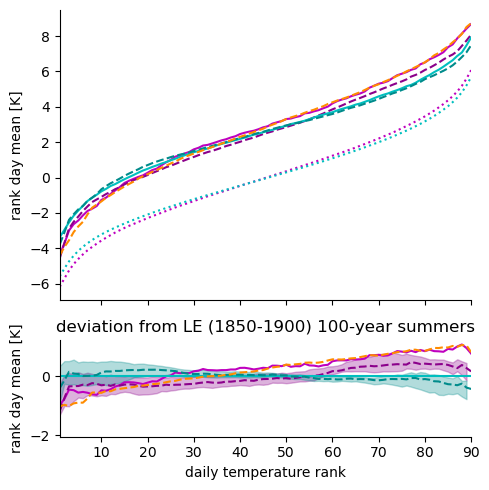

In [59]:
fig, axes = plt.subplots(nrows=2, figsize=(5,5), sharex=True, gridspec_kw=dict(height_ratios=[3,1]))
for climate in climates:
    ens = ensembles[f'{climate}-LE-all']
    axes[0].plot(np.arange(1,91), ens['stats']['RDM'], color=ens['color'], linestyle=':', label=f"{ens['label']}")
axes[0].plot([],[],color='w',label='100-year summers', alpha=0)
for climate in climates:
    for type in ['LE-all','rea']:
        ens = ensembles[f'{climate}-{type}']
        axes[0].plot(np.arange(1,91), ens['class'].expected_value('tas_anom_sorted','stats',get_threshold(100), n_bootstrap=0), color=ens['color'], linestyle=ens['linestyle'], label=ens['label'])
        
ens = ensembles[f'ssp370-2025-rea-dry']
axes[0].plot(np.arange(1,91), ens['class'].expected_value('tas_anom_sorted','stats',get_threshold(100), n_bootstrap=0), color=ens['color'], linestyle=ens['linestyle'], label=ens['label'])

ref = ensembles[f'piControl-LE-all']['class'].expected_value('tas_anom_sorted','stats',get_threshold(100), n_bootstrap=0)

for climate in climates:
    for type in ['LE-all','rea']:
        ens = ensembles[f'{climate}-{type}']
        y,l = ens['class'].expected_value('tas_anom_sorted','stats', get_threshold(100), n_bootstrap=1000)
        y -= ref
        axes[1].plot(np.arange(1,91), y, color=ens['color'], linestyle=ens['linestyle'], label=ens['label'])
        if type == 'rea':
            l = l.reshape((1000,90)) - ref.values
            lo,hi = np.percentile(l, [2.5, 97.5], axis=0)
            axes[1].fill_between(range(90), lo, hi, alpha=0.3, color=ens['color'], label=ens['label'])
            
ens = ensembles[f'ssp370-2025-rea-dry']
y = ens['class'].expected_value('tas_anom_sorted','stats',get_threshold(100), n_bootstrap=0) - ref
axes[1].plot(np.arange(1,91), y, color=ens['color'], linestyle=ens['linestyle'], label=ens['label'])
#axes[0].axhspan(np.nanpercentile(ensembles['piControl-LE-all']['data']['tas_anom'], 95), 10, color='gray', alpha=0.3)
axes[1].set_xlabel('daily temperature rank')
axes[0].set_ylabel('rank day mean [K]')
axes[1].set_ylabel('rank day mean [K]')
axes[1].set_title('deviation from LE (1850-1900) 100-year summers')
for ax in axes:
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_xticks(np.arange(0,91,10))
    ax.set_xlim(1,90)
plt.tight_layout()
savefig('rank_plots/rank_tas_overview')

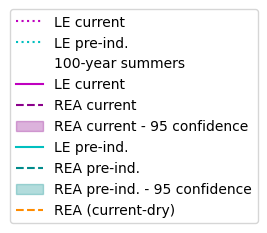

In [54]:
fig, ax = plt.subplots(figsize=(2.5,2))
ax.axis('off')
for climate in climates:
    ens = ensembles[f'{climate}-LE-all']
    ax.plot([], [], color=ens['color'], linestyle=':', label=f"{ens['label']}")
ax.plot([],[],color='w',label='100-year summers', alpha=0)
for climate in climates:
    for type in ['LE-all','rea']:
        ens = ensembles[f'{climate}-{type}']
        ax.plot([], [], color=ens['color'], linestyle=ens['linestyle'], label=ens['label'])
        if type == 'rea':
            ax.fill_between([], [], [], alpha=0.3, color=ens['color'], label=f"{ens['label']} - 95 confidence")
            
ens = ensembles[f'ssp370-2025-rea-dry']
ax.plot([], [], color=ens['color'], linestyle=ens['linestyle'], label=ens['label'])
ax.legend(loc='center')
plt.tight_layout()
savefig('rank_plots/rank_tas_overview_legend')

## surviving start conditions

In [ ]:
def get_sim_step_names(ens):
    sims = ens['data']['weight'].sim.values

    if ens['exp'].ensemble_type == 'rea':
        sims = np.array([s.split('.')[1:] for s in sims])
    elif ens['exp'].ensemble_type == 'rea_legacy':
        sims = np.array([s.split('/') for s in sims])
    else:
        assert False, "specify ensemble type"

    return sims

def get_uniqueness(ens):
    uniqueness = xr.DataArray(dims=['sim','step'], coords=dict(sim=ens['data']['weight'].sim.values,step=np.arange(0,ens['exp'].n_steps,1,'int')))
    sims = get_sim_step_names(ens)

    for step in uniqueness.step.values:
        for v in np.unique(sims[:,step]):
            same = (sims[:,step] == v)
            uniqueness[same, step] = 1 / same.sum()
    return uniqueness

In [ ]:
for ens_name, ens in ensembles.items():
    if '-x' in ens_name:
        ens['data']['uniqueness'] = get_uniqueness(ens)

In [ ]:
fig,ax = plt.subplots()
for ens_name, ens in ensembles.items():
    if 'initial' not in ens_name:
        if int(ens_name.split('-x')[-1]) < 6:
            uniqueness = ens['data']['uniqueness']
            ax.plot(uniqueness.sum('sim') / 126, color=ens['color'], label=ens_name)
ax.set_ylabel('fraction of ensemble members that are unique')
ax.set_xlabel('simulation step')
ax.set_xticks(range(0,18))
ax.legend()
savefig('meta/uniqueness')